Connected to ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_genotypes.vcf.gz")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

[E::hts_open_format] Failed to open file "Filter_tr_genotypes/UNMC-000034-01_trgt_genotypes.vcf.gz" : No such file or directory


OSError: Error opening Filter_tr_genotypes/UNMC-000034-01_trgt_genotypes.vcf.gz

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)

    for v in vcf:
        # Skip SNV records — only process STR loci
        if v.INFO.get("VT") != "str":
            continue

        motif    = v.INFO.get("MOTIF", "")
        bed_start = v.INFO.get("BED_START")
        bed_end   = v.INFO.get("BED_END")
        tr_length = (bed_end - bed_start) if bed_start is not None and bed_end is not None else None

        # MC: motif copy number per allele e.g. "3,3"
        mc_raw = None
        try:
            mc_field = v.format("MC")  # numpy array shape (n_samples, 1) — string
            if mc_field is not None:
                mc_raw = mc_field[0][0]  # e.g. "3,3"
        except Exception:
            pass

        mc_allele1, mc_allele2 = None, None
        if mc_raw:
            parts = str(mc_raw).split(",")
            try: mc_allele1 = float(parts[0])
            except: pass
            try: mc_allele2 = float(parts[1])
            except: pass

        # DP: total read depth
        dp = None
        try:
            dp_field = v.format("DP")
            if dp_field is not None:
                dp = int(dp_field[0][0])
        except Exception:
            pass

        # GT
        gt = v.gt_types[0] if v.gt_types is not None else None  # 0=HOM_REF,1=HET,2=UNKNOWN,3=HOM_ALT

        records.append({
            "CHROM":       v.CHROM,
            "POS":         v.POS,
            "ID":          v.ID,
            "BED_START":   bed_start,
            "BED_END":     bed_end,
            "TR_length":   tr_length,
            "MOTIF":       motif,
            "MOTIF_SIZE":  len(motif),
            "REFMC":       v.INFO.get("REFMC"),   # ref motif copy number
            "MC_allele1":  mc_allele1,             # called copy number allele 1
            "MC_allele2":  mc_allele2,             # called copy number allele 2
            "DP":          dp,
            "GT":          gt,
        })

    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_strkit_filtered_max_sd_ap.vcf.gz")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS      ID  BED_START  BED_END  TR_length   MOTIF  MOTIF_SIZE  \
0  chr1  14069  locus4      14070    14081         11    CCTC           4   
1  chr1  15240  locus5      15241    15255         14  GGGCCA           6   
2  chr1  15797  locus6      15798    15822         24     TGC           3   
3  chr1  16619  locus7      16620    16632         12     GCT           3   
4  chr1  16712  locus8      16713    16744         31     TGG           3   

   REFMC  MC_allele1 MC_allele2  DP  GT  
0      3         3.0       None  38   0  
1      3         3.0       None  45   0  
2      8         8.0       None  47   1  
3      4         4.0       None  57   0  
4     11        11.0       None  57   0  

Total STR loci: 2,138,480


In [ ]:
df.shape

(2138480, 13)

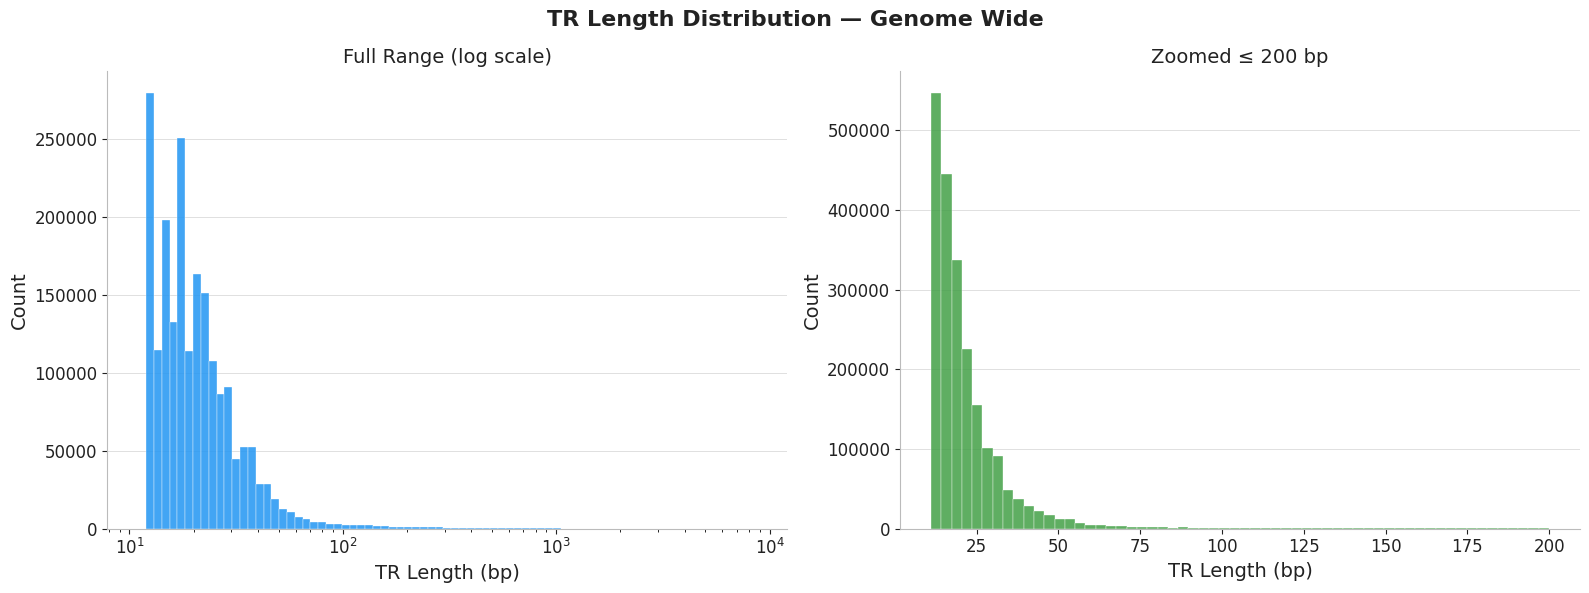

<ipython-input-5-cd3ef33a468d>:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20b", len(chroms))


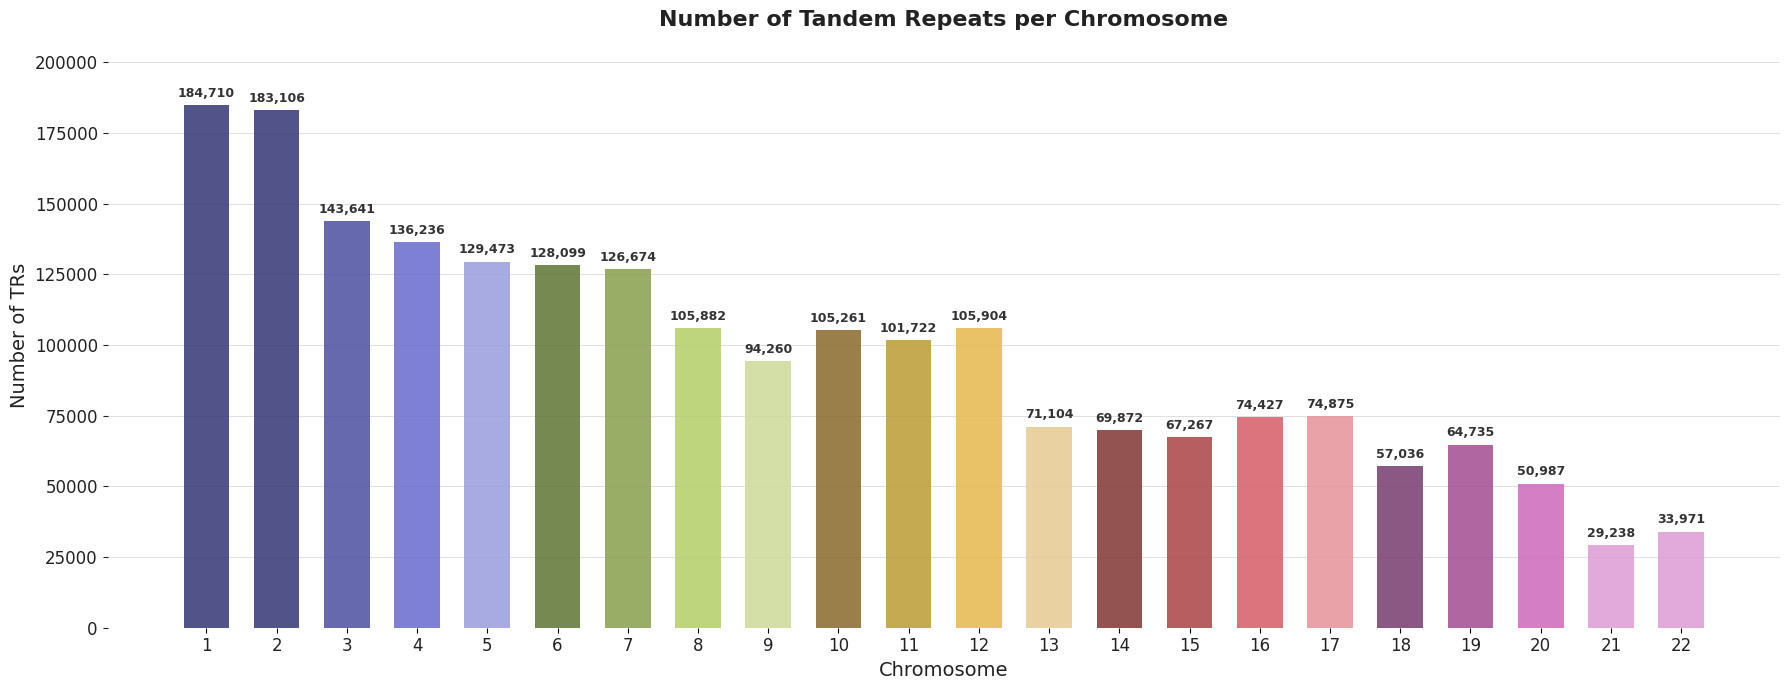

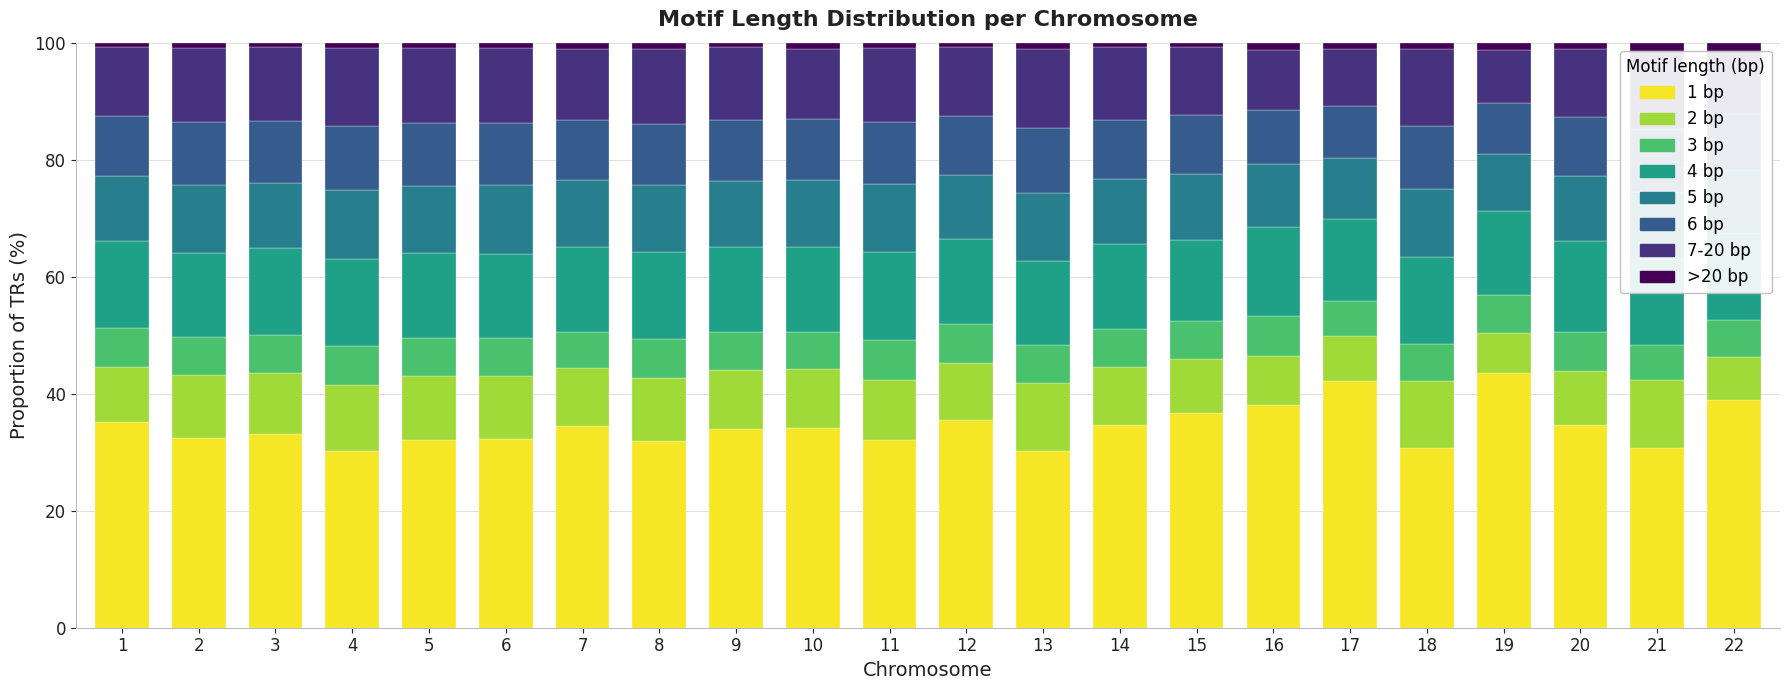

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY", "chrM"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
ax = axes[0]
ax.set_facecolor(BG)
bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[1]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 200], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 200 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_length_distribution.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════
# PLOT 2 – Number of TRs per Chromosome
# ══════════════════════════════════════════════════════════════════
canon_df = df[df["CHROM"].isin(CHR_ORDER)]
counts   = canon_df.groupby("CHROM").size()
chroms   = sort_chroms(counts.index)
counts   = counts.reindex(chroms, fill_value=0)

cmap   = plt.cm.get_cmap("tab20b", len(chroms))
colors = [cmap(i) for i in range(len(chroms))]

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs   = np.arange(len(chroms))
bars = ax.bar(xs, counts.values, width=0.65, color=colors,
              alpha=0.88, linewidth=0, zorder=3)

for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            cnt + counts.max() * 0.01,
            f"{cnt:,}", ha="center", va="bottom",
            fontsize=ANNOT_SIZE, color="#333", fontweight="bold")

ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Number of TRs",  fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",     fontsize=LABEL_SIZE, color="#222")
ax.set_title("Number of Tandem Repeats per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(axis="y", colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════
# PLOT 3 – Motif Proportion per Chromosome (stacked bar)
# ══════════════════════════════════════════════════════════════════
def classify_motif_size(size):
    if size == 1:    return "1"
    elif size == 2:  return "2"
    elif size == 3:  return "3"
    elif size == 4:  return "4"
    elif size == 5:  return "5"
    elif size == 6:  return "6"
    elif size <= 20: return "7-20"
    else:            return ">20"

CATEGORIES = ["1", "2", "3", "4", "5", "6", "7-20", ">20"]
COLORS = {
    "1":    "#f5e626", "2": "#a0da39", "3":    "#4ac16d",
    "4":    "#1fa187", "5": "#277f8e", "6":    "#365c8d",
    "7-20": "#46327e", ">20":          "#440154",
}

df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(classify_motif_size)
plot_df = df[df["CHROM"].isin(CHR_ORDER[:-1])].copy()  # exclude chrM
chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]

counts_m = (
    plot_df.groupby(["CHROM", "MOTIF_CLASS"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=chroms, columns=CATEGORIES, fill_value=0)
)
proportions = counts_m.div(counts_m.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs      = np.arange(len(chroms))
bar_w   = 0.7
bottoms = np.zeros(len(chroms))

for cat in CATEGORIES:
    vals = proportions[cat].values
    ax.bar(xs, vals, width=bar_w, bottom=bottoms,
           color=COLORS[cat], linewidth=0.2, edgecolor="white")
    bottoms += vals

ax.set_xlim(-0.6, len(chroms) - 0.4)
ax.set_ylim(0, 100)
ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Proportion of TRs (%)", fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",            fontsize=LABEL_SIZE, color="#222")
ax.set_title("Motif Length Distribution per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=COLORS[c], label=f"{c} bp")
                  for c in CATEGORIES]
ax.legend(handles=legend_patches, title="Motif length (bp)",
          title_fontsize=TICK_SIZE, fontsize=TICK_SIZE,
          loc="upper right", framealpha=0.9, edgecolor=SPINE_COLOR)

plt.tight_layout()
plt.savefig("plot_motif_proportion_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


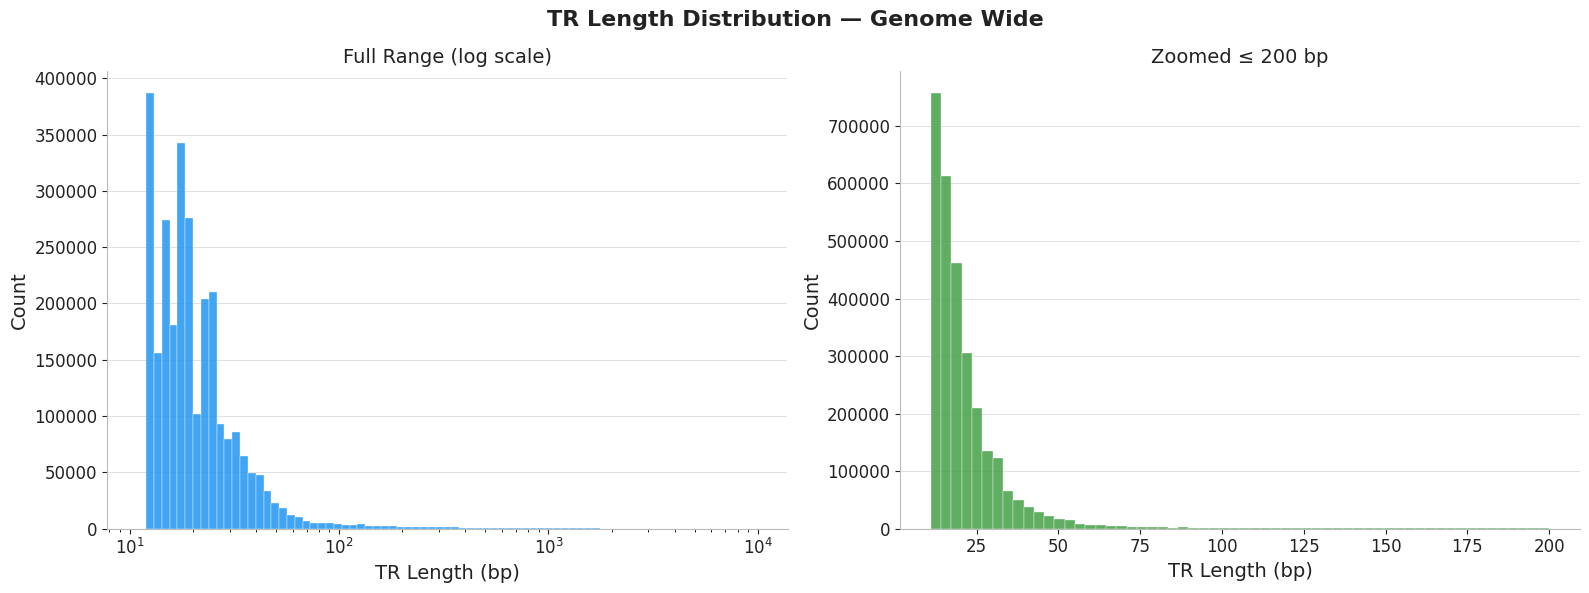

<ipython-input-7-cd3ef33a468d>:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20b", len(chroms))


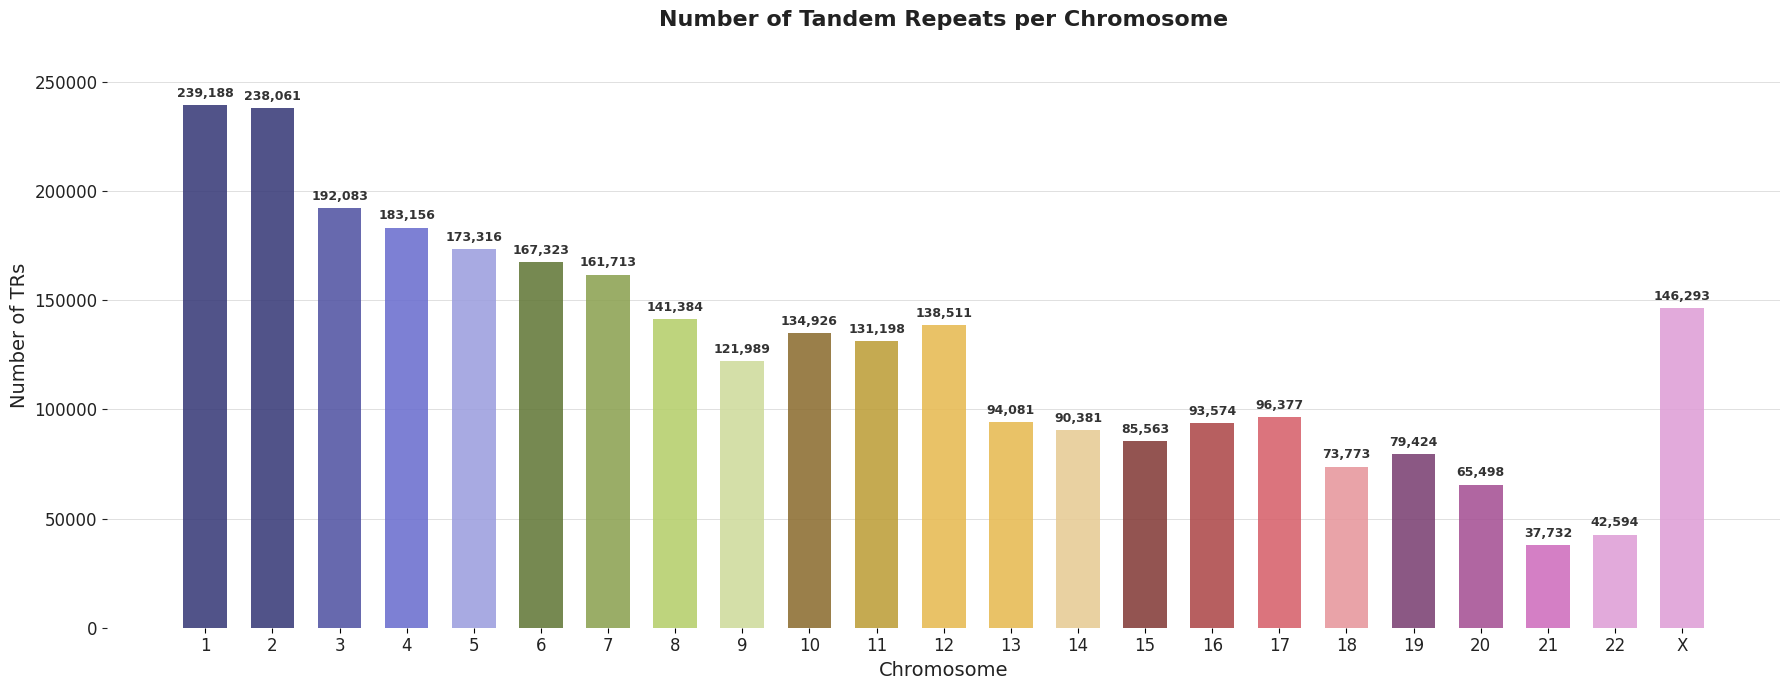

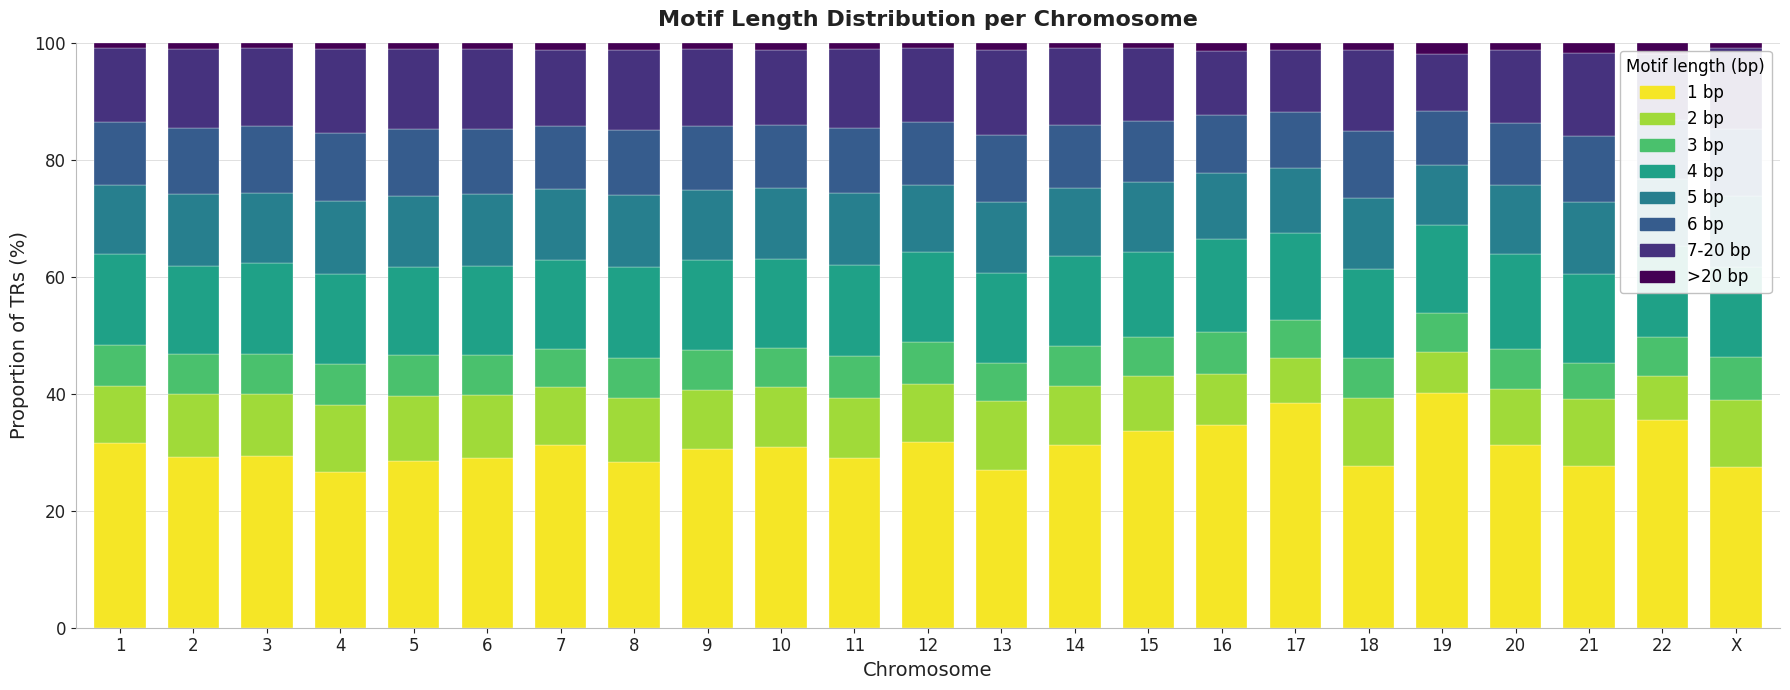

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY", "chrM"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
ax = axes[0]
ax.set_facecolor(BG)
bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[1]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 200], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 200 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_length_distribution.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════
# PLOT 2 – Number of TRs per Chromosome
# ══════════════════════════════════════════════════════════════════
canon_df = df[df["CHROM"].isin(CHR_ORDER)]
counts   = canon_df.groupby("CHROM").size()
chroms   = sort_chroms(counts.index)
counts   = counts.reindex(chroms, fill_value=0)

cmap   = plt.cm.get_cmap("tab20b", len(chroms))
colors = [cmap(i) for i in range(len(chroms))]

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs   = np.arange(len(chroms))
bars = ax.bar(xs, counts.values, width=0.65, color=colors,
              alpha=0.88, linewidth=0, zorder=3)

for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            cnt + counts.max() * 0.01,
            f"{cnt:,}", ha="center", va="bottom",
            fontsize=ANNOT_SIZE, color="#333", fontweight="bold")

ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Number of TRs",  fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",     fontsize=LABEL_SIZE, color="#222")
ax.set_title("Number of Tandem Repeats per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(axis="y", colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════
# PLOT 3 – Motif Proportion per Chromosome (stacked bar)
# ══════════════════════════════════════════════════════════════════
def classify_motif_size(size):
    if size == 1:    return "1"
    elif size == 2:  return "2"
    elif size == 3:  return "3"
    elif size == 4:  return "4"
    elif size == 5:  return "5"
    elif size == 6:  return "6"
    elif size <= 20: return "7-20"
    else:            return ">20"

CATEGORIES = ["1", "2", "3", "4", "5", "6", "7-20", ">20"]
COLORS = {
    "1":    "#f5e626", "2": "#a0da39", "3":    "#4ac16d",
    "4":    "#1fa187", "5": "#277f8e", "6":    "#365c8d",
    "7-20": "#46327e", ">20":          "#440154",
}

df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(classify_motif_size)
plot_df = df[df["CHROM"].isin(CHR_ORDER[:-1])].copy()  # exclude chrM
chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]

counts_m = (
    plot_df.groupby(["CHROM", "MOTIF_CLASS"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=chroms, columns=CATEGORIES, fill_value=0)
)
proportions = counts_m.div(counts_m.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs      = np.arange(len(chroms))
bar_w   = 0.7
bottoms = np.zeros(len(chroms))

for cat in CATEGORIES:
    vals = proportions[cat].values
    ax.bar(xs, vals, width=bar_w, bottom=bottoms,
           color=COLORS[cat], linewidth=0.2, edgecolor="white")
    bottoms += vals

ax.set_xlim(-0.6, len(chroms) - 0.4)
ax.set_ylim(0, 100)
ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Proportion of TRs (%)", fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",            fontsize=LABEL_SIZE, color="#222")
ax.set_title("Motif Length Distribution per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=COLORS[c], label=f"{c} bp")
                  for c in CATEGORIES]
ax.legend(handles=legend_patches, title="Motif length (bp)",
          title_fontsize=TICK_SIZE, fontsize=TICK_SIZE,
          loc="upper right", framealpha=0.9, edgecolor=SPINE_COLOR)

plt.tight_layout()
plt.savefig("plot_motif_proportion_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
df.shape

(2928138, 10)

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928138 entries, 0 to 2928137
Data columns (total 10 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   CHROM        object
 1   POS          int64 
 2   END          int64 
 3   TRID         object
 4   MOTIFS       object
 5   MOTIF_SIZE   int64 
 6   AL_allele1   int64 
 7   AL_allele2   int64 
 8   TR_length    int64 
 9   MOTIF_CLASS  object
dtypes: int64(6), object(4)
memory usage: 223.4+ MB


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928138 entries, 0 to 2928137
Data columns (total 10 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   CHROM        object
 1   POS          int64 
 2   END          int64 
 3   TRID         object
 4   MOTIFS       object
 5   MOTIF_SIZE   int64 
 6   AL_allele1   int64 
 7   AL_allele2   int64 
 8   TR_length    int64 
 9   MOTIF_CLASS  object
dtypes: int64(6), object(4)
memory usage: 223.4+ MB


,POS,END,MOTIF_SIZE,AL_allele1,AL_allele2,TR_length
count,2.928138e+06,2.928138e+06,2.928138e+06,2.928138e+06,2.928138e+06,2.928138e+06
mean,7.883716e+07,7.883718e+07,4.237320e+00,2.530477e+01,2.651401e+01,2.532825e+01
std,5.508437e+07,5.508437e+07,6.496153e+00,6.668247e+01,9.010838e+01,7.572882e+01
min,1.018600e+04,1.019800e+04,1.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01
25%,3.410495e+07,3.410499e+07,1.000000e+00,1.400000e+01,1.400000e+01,1.400000e+01
50%,6.946041e+07,6.946043e+07,4.000000e+00,1.800000e+01,1.800000e+01,1.800000e+01
75%,1.139173e+08,1.139174e+08,6.000000e+00,2.400000e+01,2.500000e+01,2.400000e+01
max,2.489452e+08,2.489452e+08,1.882000e+03,9.154000e+03,1.320700e+04,9.856000e+03


In [ ]:
df.shape
df.info()
df["TR_length"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2928138 entries, 0 to 2928137
Data columns (total 10 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   CHROM        object
 1   POS          int64 
 2   END          int64 
 3   TRID         object
 4   MOTIFS       object
 5   MOTIF_SIZE   int64 
 6   AL_allele1   int64 
 7   AL_allele2   int64 
 8   TR_length    int64 
 9   MOTIF_CLASS  object
dtypes: int64(6), object(4)
memory usage: 223.4+ MB


count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64

In [ ]:
df.shape
#df.info()
df["TR_length"]

0          11
1          14
2          24
3          12
4          31
           ..
2928133    16
2928134    14
2928135    11
2928136    17
2928137    12
Name: TR_length, Length: 2928138, dtype: int64

In [ ]:
df.shape
#df.info()
df["TR_length"]

0          11
1          14
2          24
3          12
4          31
           ..
2928133    16
2928134    14
2928135    11
2928136    17
2928137    12
Name: TR_length, Length: 2928138, dtype: int64

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["MOTIF_SIZE"].value_counts().sort_index()

MOTIF_SIZE
1       889905
2       300942
3       201094
4       449049
5       349950
         ...  
807          1
818          1
819          1
889          1
1882         1
Name: count, Length: 280, dtype: int64

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["TR_length"].max()

9856

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

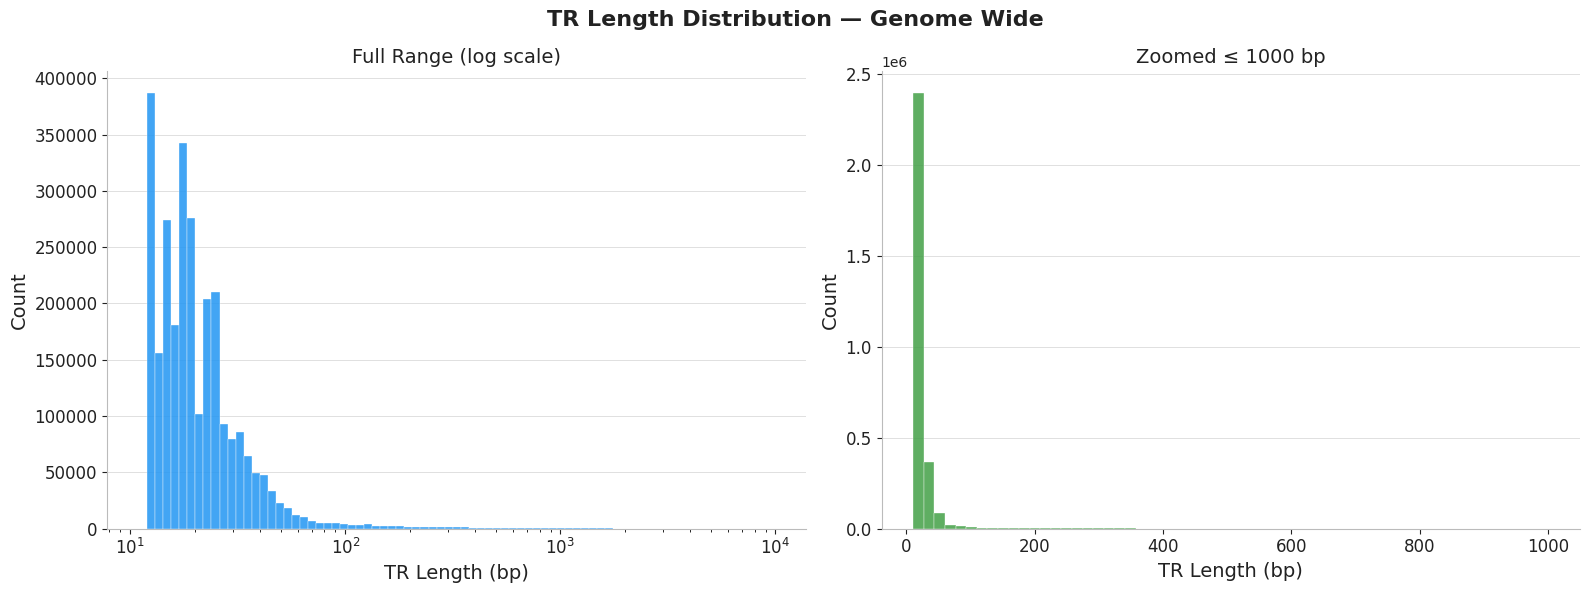

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
ax = axes[0]
ax.set_facecolor(BG)
bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[1]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

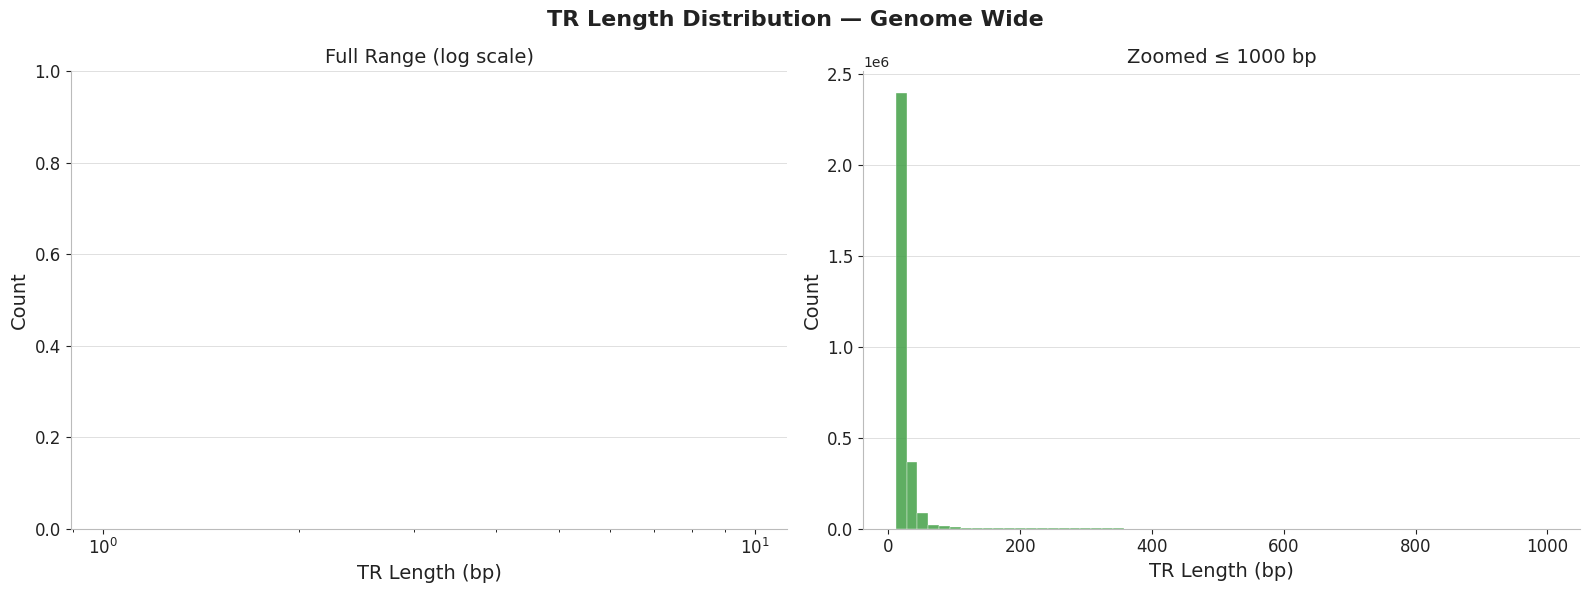

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
ax = axes[0]
ax.set_facecolor(BG)
bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
#ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
 #       edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[1]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

TypeError: 'Axes' object is not subscriptable

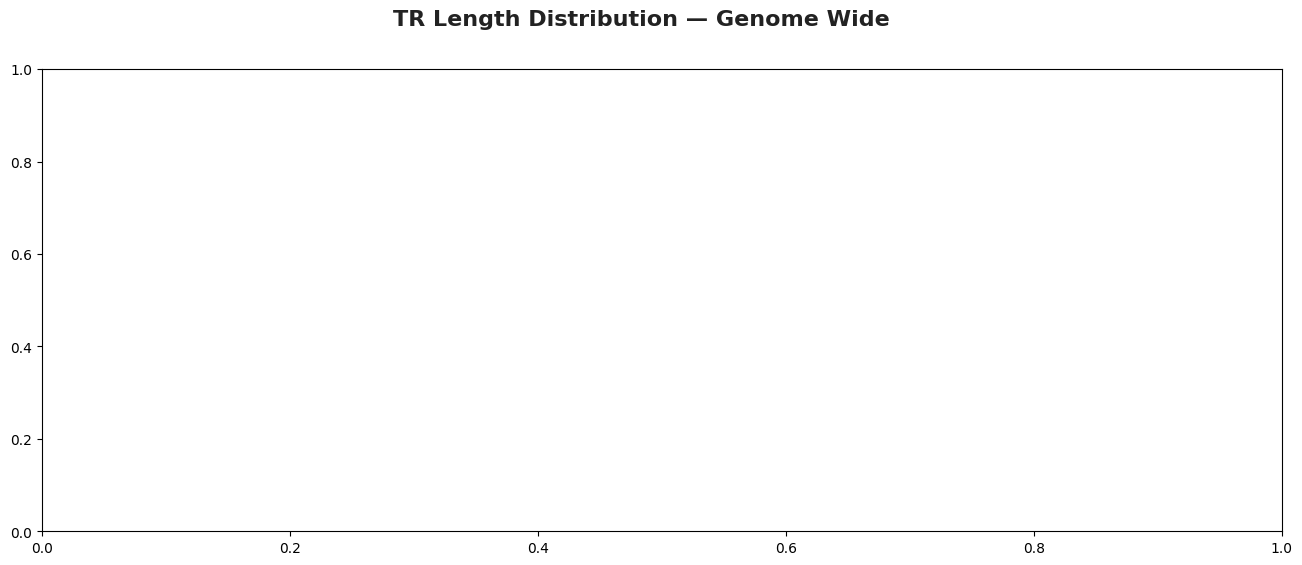

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[1]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

TypeError: 'Axes' object is not subscriptable

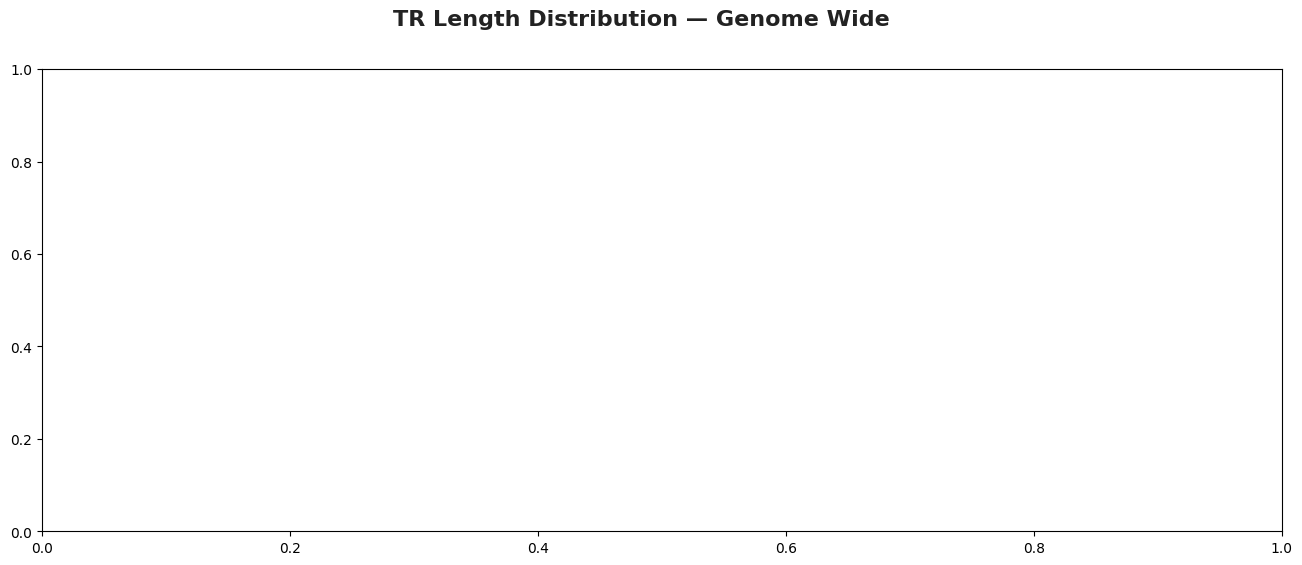

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes[0]
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

TypeError: 'Axes' object is not iterable

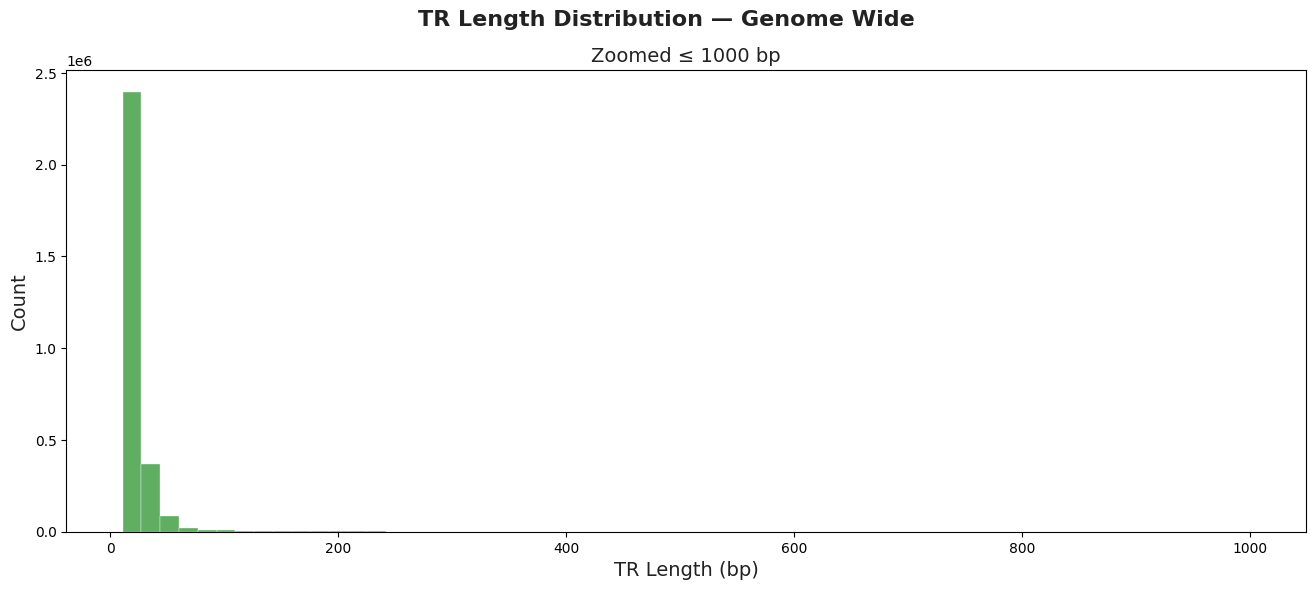

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

for ax in axes:
    ax.tick_params(colors="#222", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

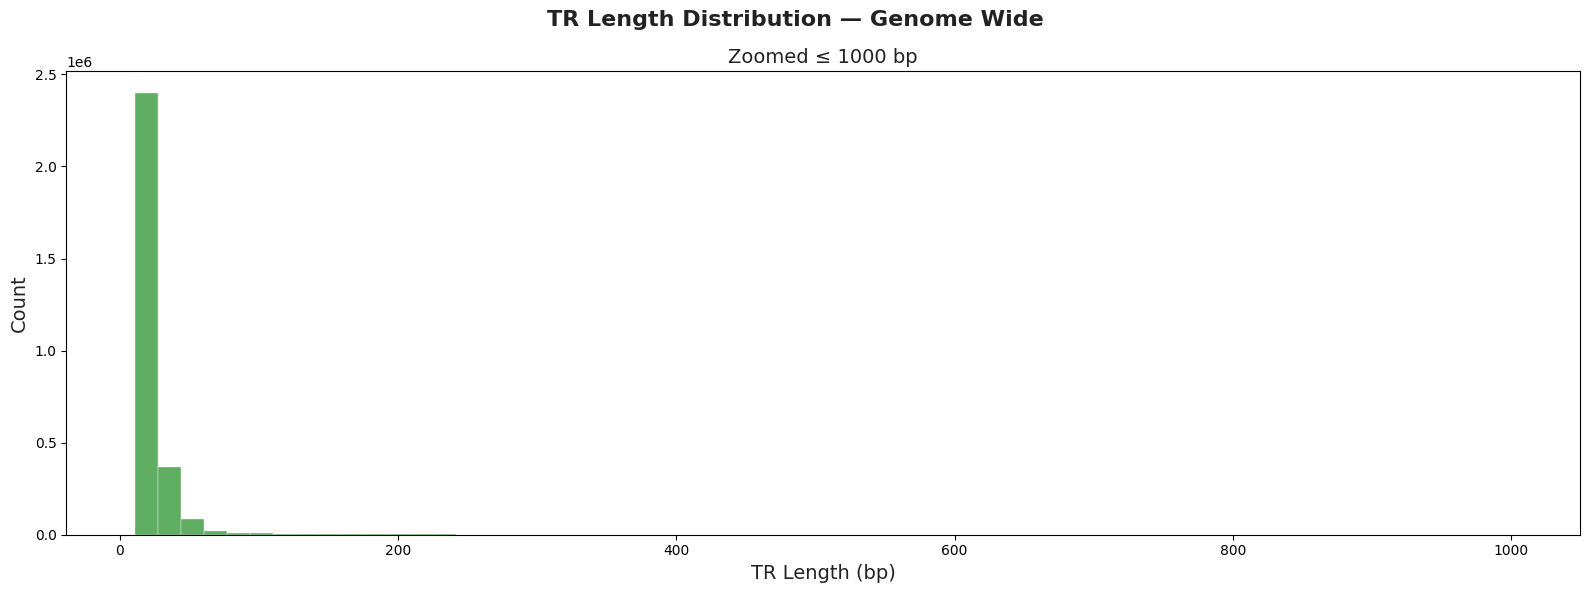

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

lengths = df["TR_length"].dropna()
lengths = lengths[lengths > 0]

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
ax = axes
ax.set_facecolor(BG)
ax.hist(lengths[lengths <= 1000], bins=60, color="#43a047", alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# for ax in axes:
#     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
#     ax.spines[["top", "right"]].set_visible(False)
#     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
#     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
#     ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("plot_tr_length_distribution.png", dpi=180,
 #           bbox_inches="tight", facecolor=BG)
plt.show()

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
df.shape
#df.info()
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
df.shape
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
df["TR_length"].describe()
df["TR_length"].max()
df["TR_length"].min()

11

In [ ]:
df.shape
#
print(df["TR_length"].describe())
print(f"Max: {df['TR_length'].max()}")
print(f"Min: {df['TR_length'].min()}")

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64
Max: 9856
Min: 11


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]
ax = axes
ax.set_facecolor(BG)

data = lengths[lengths <= 10000].values

# ── Line through histogram bin midpoints (no smoothing) ───────────
counts, bin_edges = np.histogram(data, bins=60)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.plot(bin_centers, counts, color="#43a047", linewidth=2)
ax.fill_between(bin_centers, counts, alpha=0.15, color="#43a047")  # optional

ax.set_title("TR Length Distribution ≤ 10,000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]
ax = axes
ax.set_facecolor(BG)

data = lengths[lengths <= 10000].values

# ── Line through histogram bin midpoints (no smoothing) ───────────
counts, bin_edges = np.histogram(data, bins=60)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.plot(bin_centers, counts, color="#43a047", linewidth=2)
ax.fill_between(bin_centers, counts, alpha=0.15, color="#43a047")  # optional

ax.set_title("TR Length Distribution ≤ 10,000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

In [ ]:
ax = axes
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data <= 10000].values

# ── Line through histogram bin midpoints (no smoothing) ───────────
counts, bin_edges = np.histogram(data, bins=60)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.plot(bin_centers, counts, color="#43a047", linewidth=2)
ax.fill_between(bin_centers, counts, alpha=0.15, color="#43a047")  # optional

ax.set_title("TR Length Distribution ≤ 10,000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

Restarted ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
df.shape
#
print(df["TR_length"].describe())
print(f"Max: {df['TR_length'].max()}")
print(f"Min: {df['TR_length'].min()}")

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64
Max: 9856
Min: 11


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

In [ ]:
ax = axes
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data <= 10000].values

# ── Line through histogram bin midpoints (no smoothing) ───────────
counts, bin_edges = np.histogram(data, bins=60)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.plot(bin_centers, counts, color="#43a047", linewidth=2)
ax.fill_between(bin_centers, counts, alpha=0.15, color="#43a047")  # optional

ax.set_title("TR Length Distribution ≤ 10,000 bp", fontsize=TITLE_SIZE - 2, color="#222")
ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

NameError: name 'axes' is not defined

In [ ]:
df.shape
#
print(df["TR_length"].describe())
print(f"Max: {df['TR_length'].max()}")
print(f"Min: {df['TR_length'].min()}")

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64
Max: 9856
Min: 11


In [ ]:
df.shape
#
print(df["TR_length"].describe())
print(f"Max: {df['TR_length'].max()}")
print(f"Min: {df['TR_length'].min()}")
print(df.describe())

count    2.928138e+06
mean     2.532825e+01
std      7.572882e+01
min      1.100000e+01
25%      1.400000e+01
50%      1.800000e+01
75%      2.400000e+01
max      9.856000e+03
Name: TR_length, dtype: float64
Max: 9856
Min: 11
                POS           END    MOTIF_SIZE    AL_allele1    AL_allele2  \
count  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06   
mean   7.883716e+07  7.883718e+07  4.237320e+00  2.530477e+01  2.651401e+01   
std    5.508437e+07  5.508437e+07  6.496153e+00  6.668247e+01  9.010838e+01   
min    1.018600e+04  1.019800e+04  1.000000e+00  0.000000e+00  0.000000e+00   
25%    3.410495e+07  3.410499e+07  1.000000e+00  1.400000e+01  1.400000e+01   
50%    6.946041e+07  6.946043e+07  4.000000e+00  1.800000e+01  1.800000e+01   
75%    1.139173e+08  1.139174e+08  6.000000e+00  2.400000e+01  2.500000e+01   
max    2.489452e+08  2.489452e+08  1.882000e+03  9.154000e+03  1.320700e+04   

          TR_length  
count  2.928138e+06  
mean   2.532825e+0

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

In [ ]:
# ── Settings ──────────────────────────────────────────────────────
BG          = "white"
LABEL_SIZE  = 13
TICK_SIZE   = 11
TITLE_SIZE  = 15
SPINE_COLOR = "#bbbbbb"
GRID_COLOR  = "#e0e0e0"

# ── Data ──────────────────────────────────────────────────────────
data = df["TR_length"].dropna()
data = data[data > 0]

# ── Bin setup: fine bins up to 400 bp (matches paper range) ───────
MAX_BP  = 400
BINS    = 400                          # 1 bp per bin = maximum detail, no smoothing
data_clipped = data[data <= MAX_BP]

counts, bin_edges = np.histogram(data_clipped, bins=BINS,
                                 range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Convert counts → density (counts / total / bin_width)
bin_width = bin_edges[1] - bin_edges[0]
density   = counts / (len(data) * bin_width)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2, zorder=3)
ax.fill_between(bin_centers, density, alpha=0.08, color="#333333")

# ── Log y-axis ────────────────────────────────────────────────────
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

# ── STR annotation box (1-6bp peak) ──────────────────────────────
ax.annotate("STRs (1–6 bp)", xy=(18, density[15]), xytext=(40, density[5]),
            fontsize=10, color="#333",
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbb", lw=0.8))

# ── Axes formatting ───────────────────────────────────────────────
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("Motif length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",     fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# ── TR count annotation ───────────────────────────────────────────
ax.text(0.98, 0.97, f"Total TRs: {len(data):,}",
        transform=ax.transAxes, fontsize=10, color="#444",
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

<ipython-input-9-0520f32cfadb>:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
# ── Settings ──────────────────────────────────────────────────────
BG          = "white"
LABEL_SIZE  = 13
TICK_SIZE   = 11
TITLE_SIZE  = 15
SPINE_COLOR = "#bbbbbb"
GRID_COLOR  = "#e0e0e0"

# ── Data ──────────────────────────────────────────────────────────
data = df["TR_length"].dropna()
data = data[data > 0]

# ── Bin setup: fine bins up to 400 bp (matches paper range) ───────
MAX_BP  = 400
BINS    = 400                          # 1 bp per bin = maximum detail, no smoothing
data_clipped = data[data <= MAX_BP]

counts, bin_edges = np.histogram(data_clipped, bins=BINS,
                                 range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Convert counts → density (counts / total / bin_width)
bin_width = bin_edges[1] - bin_edges[0]
density   = counts / (len(data) * bin_width)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2, zorder=3)
ax.fill_between(bin_centers, density, alpha=0.08, color="#333333")

# ── Log y-axis ────────────────────────────────────────────────────
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


# ── Axes formatting ───────────────────────────────────────────────
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("Motif length (bp)", fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",     fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# ── TR count annotation ───────────────────────────────────────────
ax.text(0.98, 0.97, f"Total TRs: {len(data):,}",
        transform=ax.transAxes, fontsize=10, color="#444",
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", lw=0.8))

plt.tight_layout()
#plt.savefig("plot_tr_density.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()
# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

IndentationError: unexpected indent (<ipython-input-10-0c97f713e4e0>, line 63)

Text(0.5, 0.98, 'TR Length Distribution — Genome Wide')

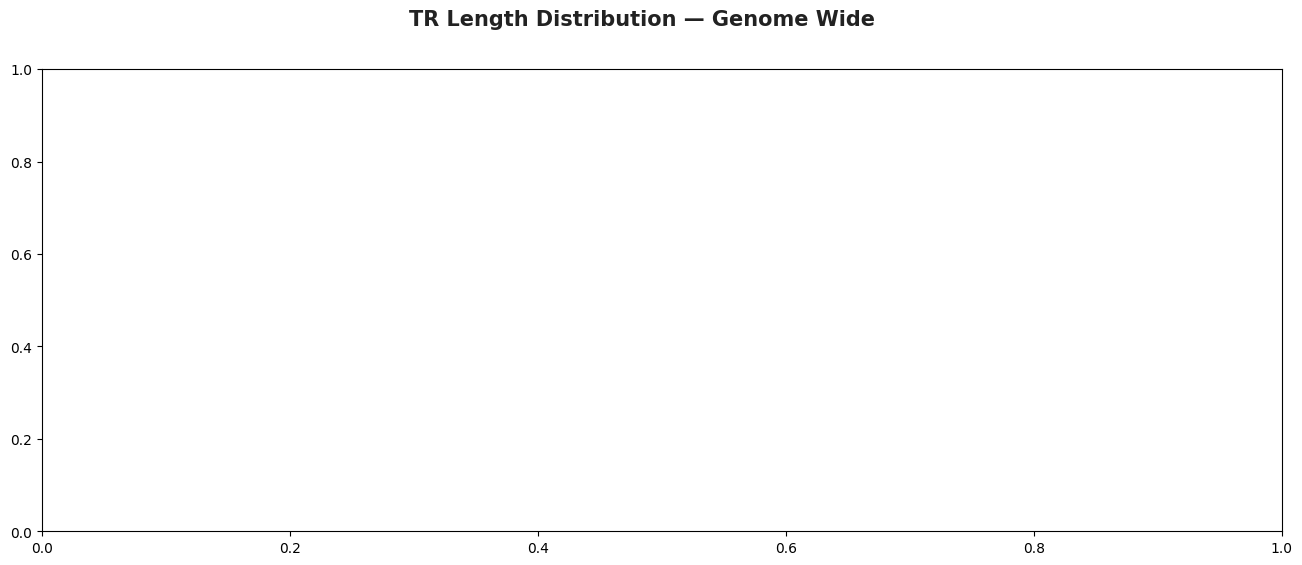

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

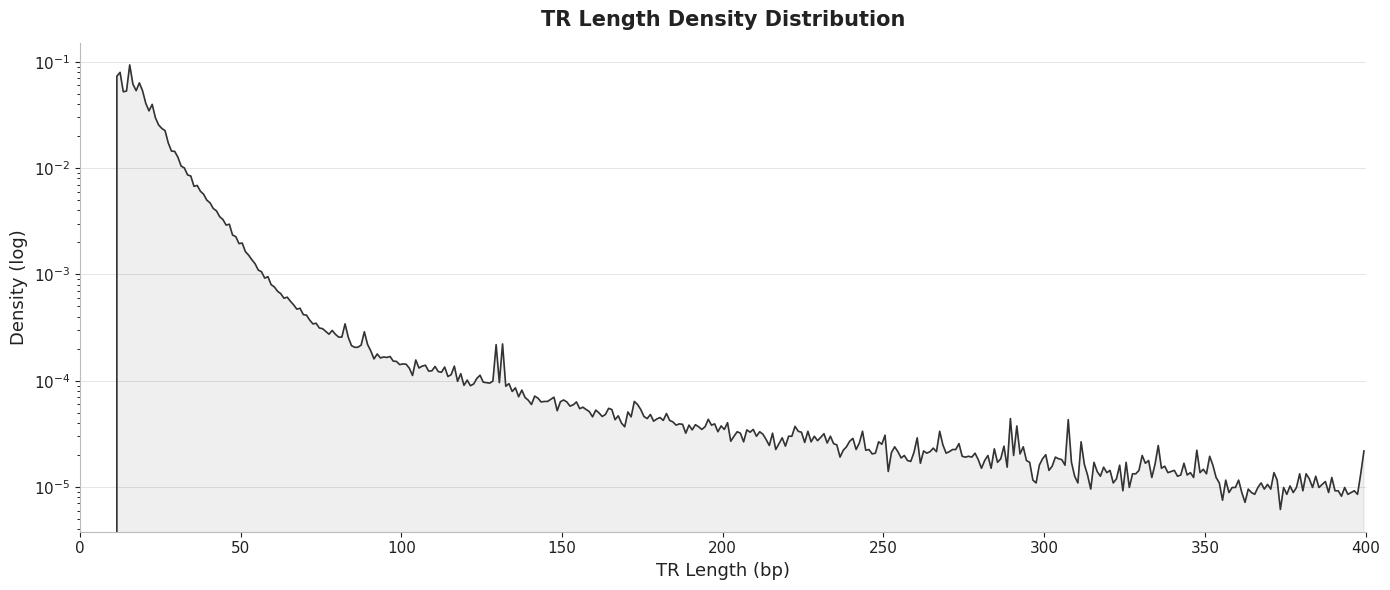

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 400
BINS   = 400

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.fill_between(bin_centers, density, alpha=0.08, color="#333333")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

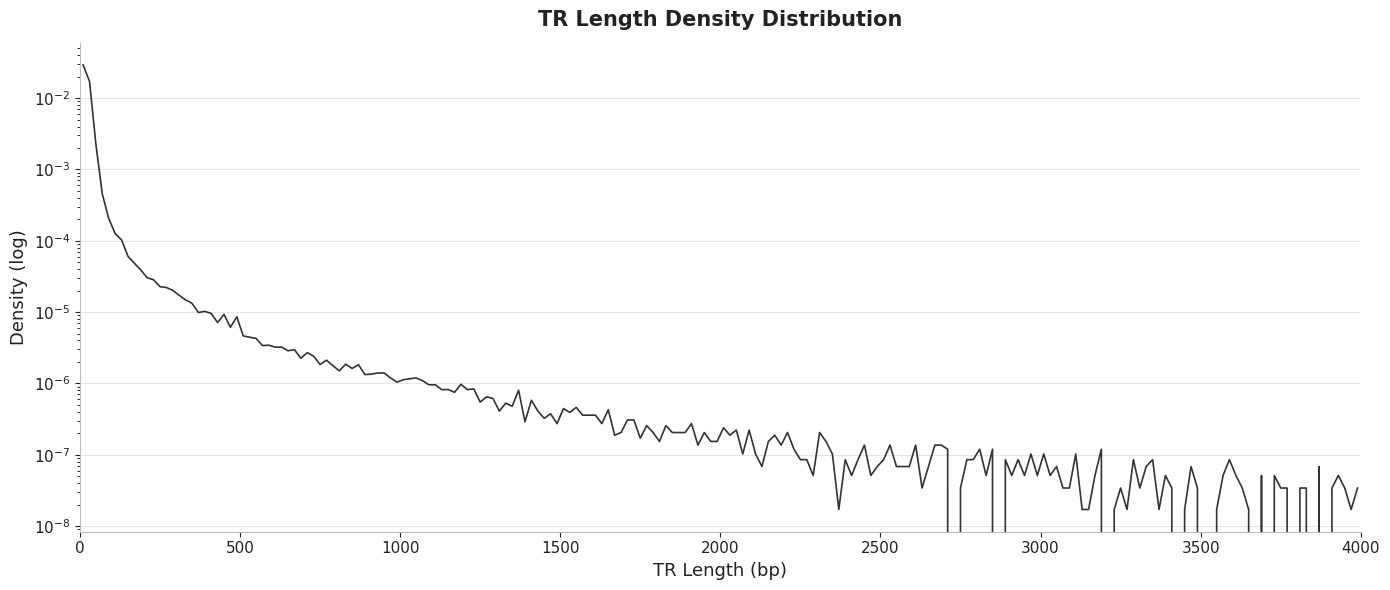

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 4000
BINS   = 200

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

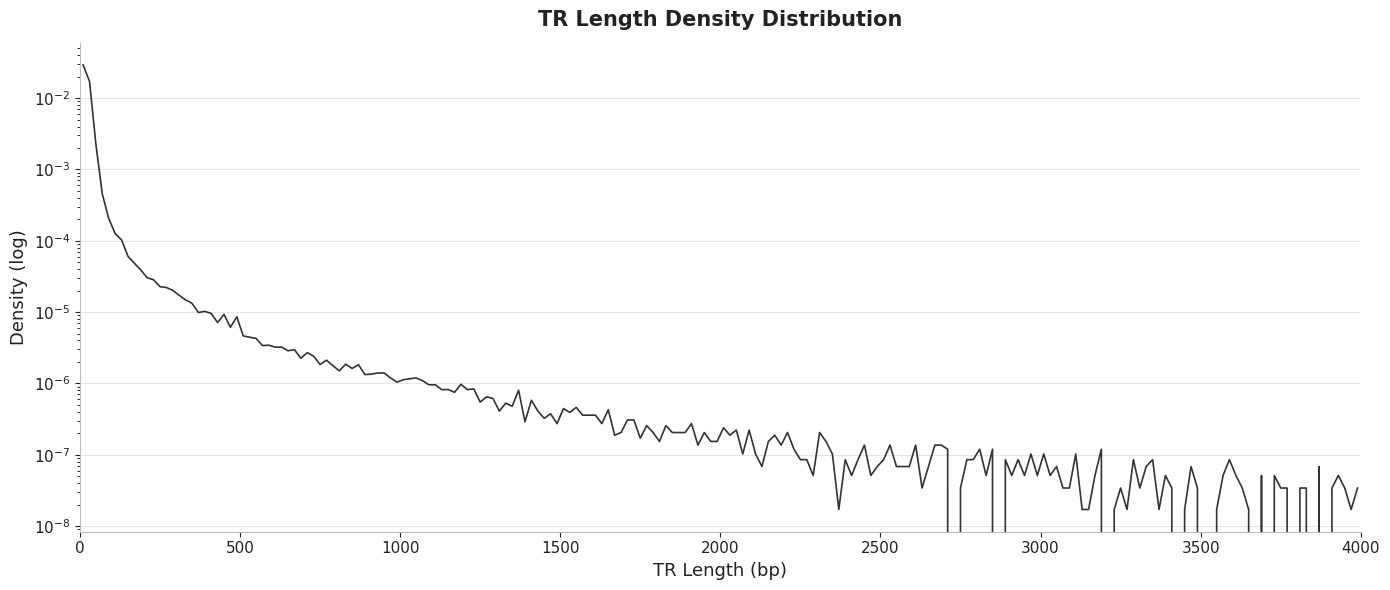

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 4000
BINS   = 200

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

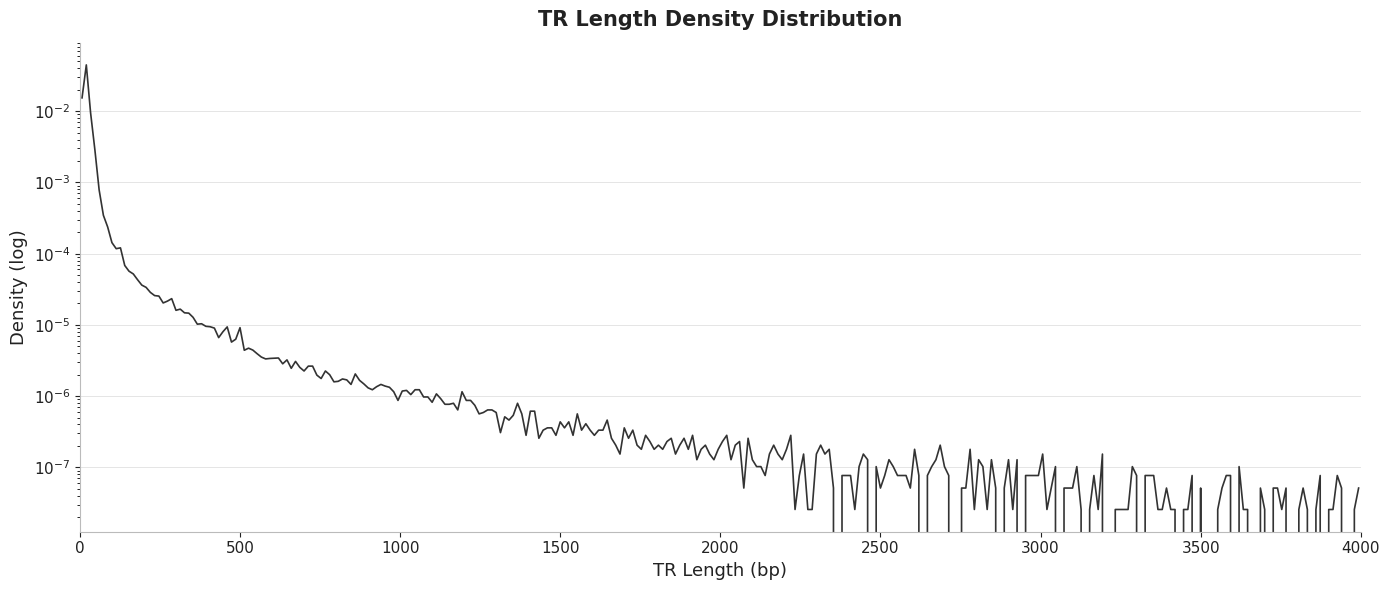

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 4000
BINS   = 300

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

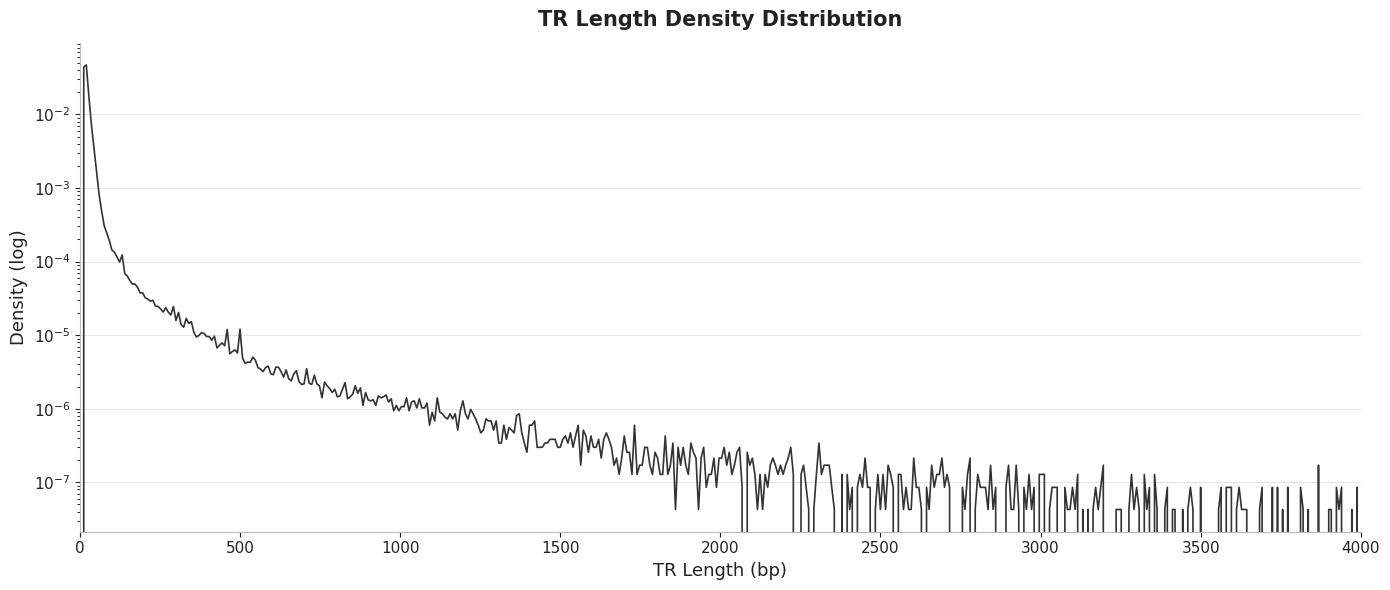

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 4000
BINS   = 500

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

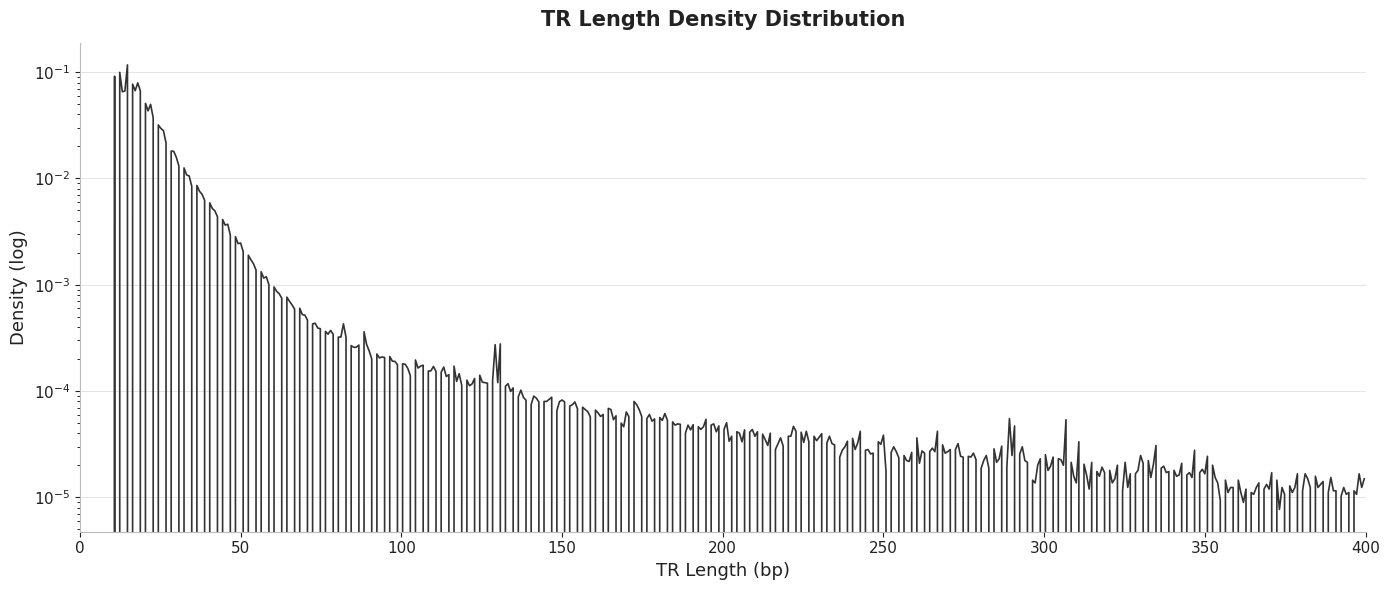

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 400
BINS   = 500

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

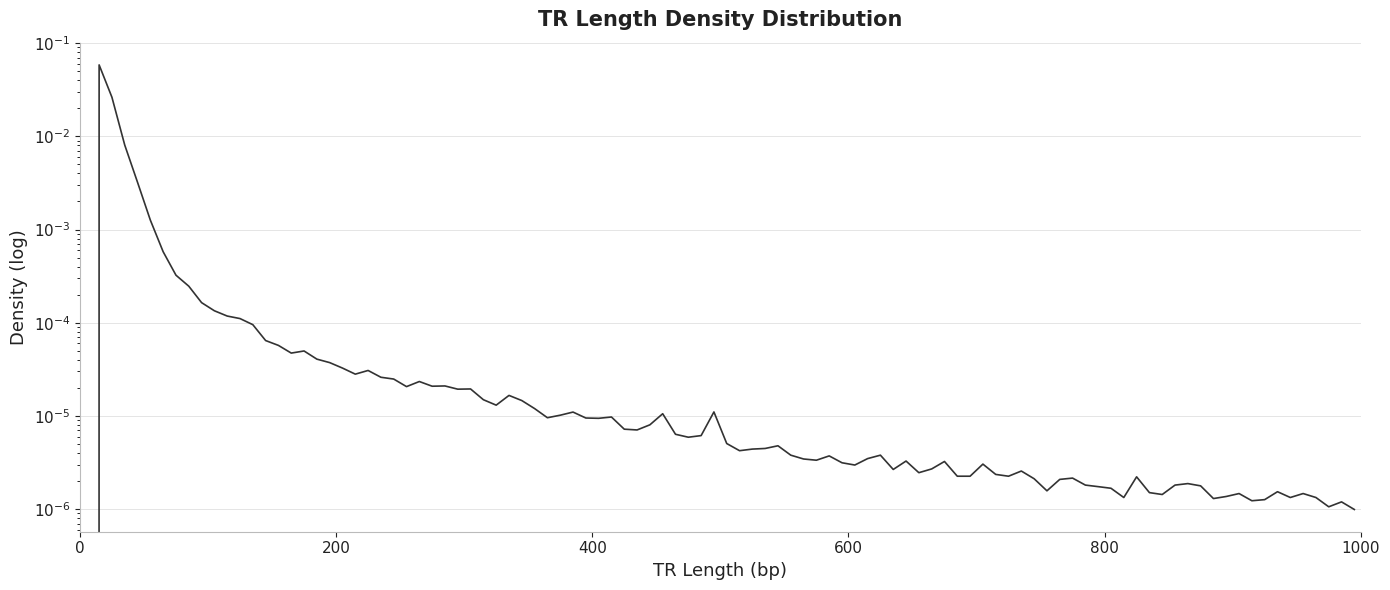

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 1000
BINS   = 100

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

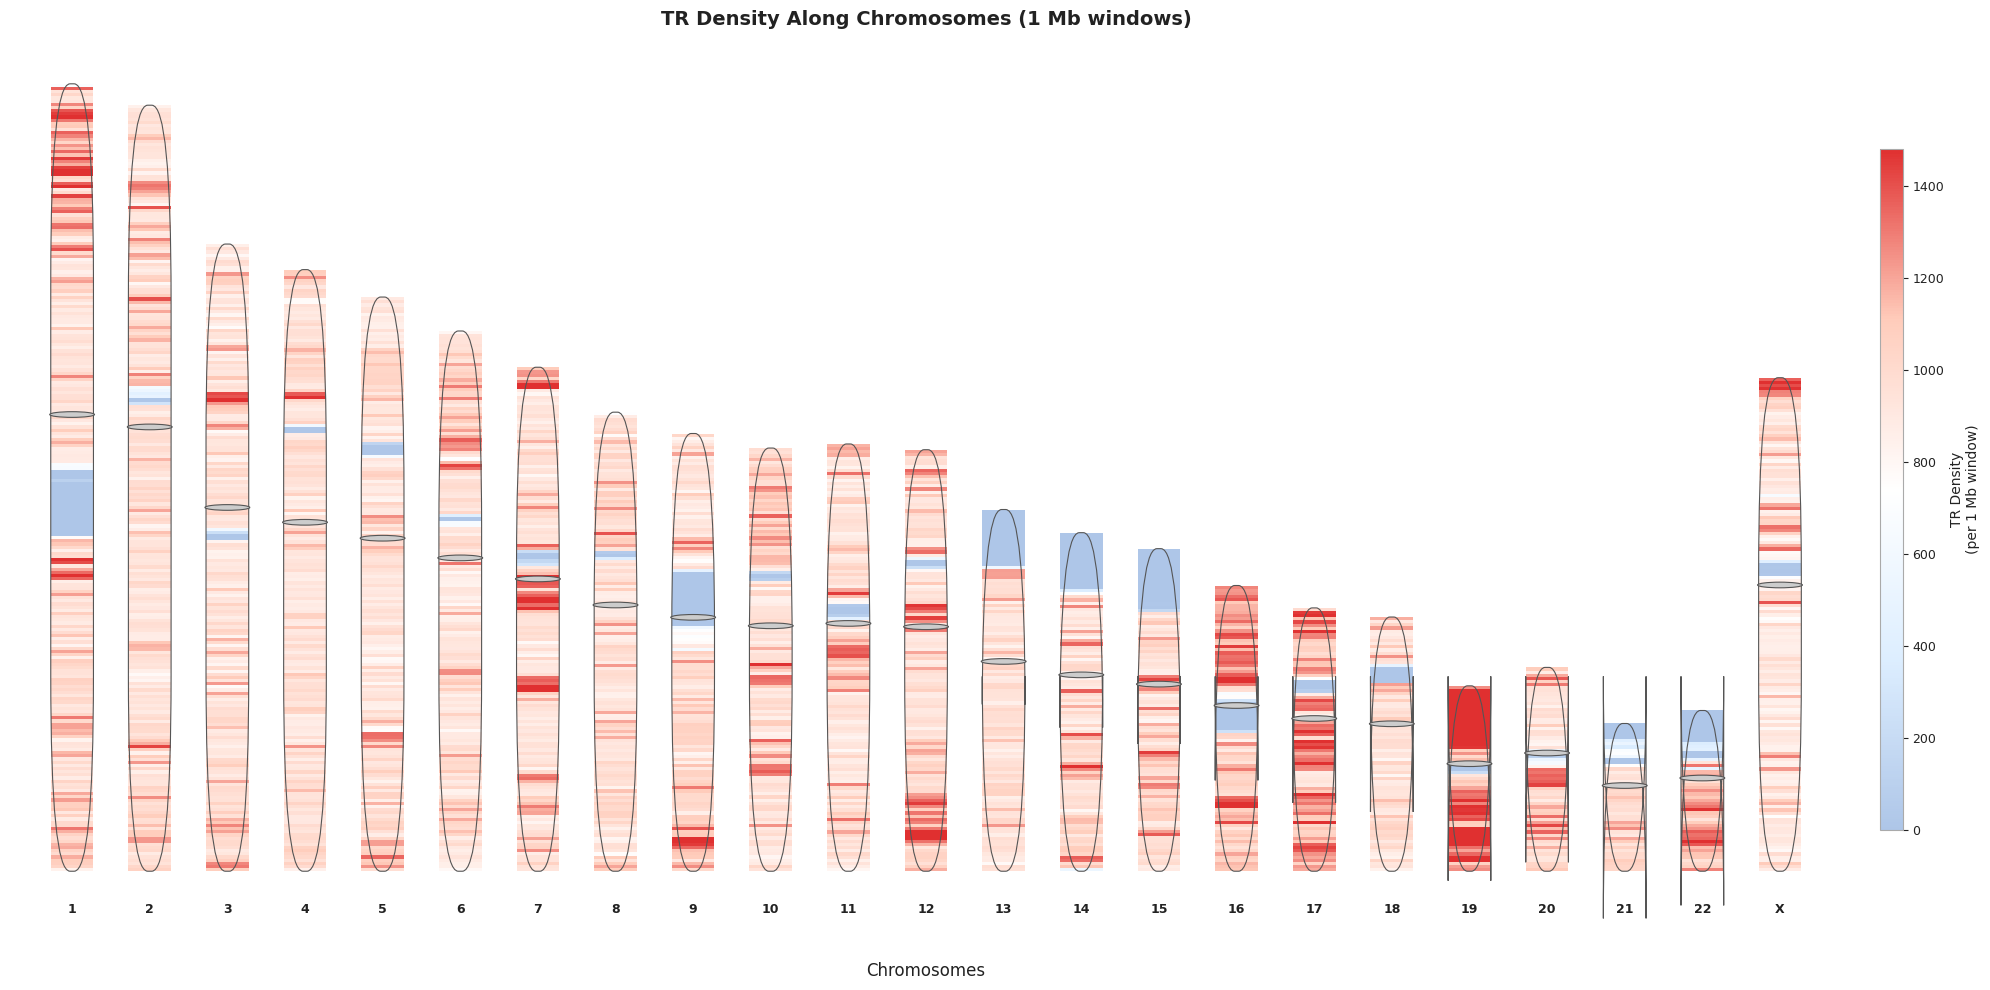

Saved: plot_chrom_ideogram.png


In [ ]:
##3 ══════════════════════════════════════════════════════════════════
# PLOT 4 – TR distribution by Motif Size along the genome 
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import pandas as pd

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000   # 1 Mb windows

# ── Colormap: light blue (low) → white → red (high) ──────────────
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "tr_density", ["#aec6e8", "#ddeeff", "#ffffff", "#ffccbb", "#e03030"]
)

def draw_chromosome(ax, x_center, chrom, density_windows, max_density,
                    chrom_len, max_len, bar_width=0.4):
    """
    Draw a single chromosome ideogram with density-colored windows.
    x_center : horizontal position
    density_windows : array of density values per 1Mb window
    """
    scale     = chrom_len / max_len          # relative height
    bar_h     = scale                        # normalized height (0-1 space)
    n_windows = len(density_windows)
    win_h     = bar_h / n_windows            # height of each window

    norm = Normalize(vmin=0, vmax=max_density)

    # Draw each window as a colored rectangle
    for j, dens in enumerate(density_windows):
        y     = bar_h - (j + 1) * win_h     # top-to-bottom
        color = CMAP(norm(dens))
        rect  = mpatches.FancyBboxPatch(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            boxstyle="square,pad=0",
            linewidth=0, facecolor=color
        )
        ax.add_patch(rect)

    # Chromosome outline with rounded caps
    outline = mpatches.FancyBboxPatch(
        (x_center - bar_width / 2, 0),
        bar_width, bar_h,
        boxstyle=f"round,pad=0,rounding_size={bar_width * 0.45}",
        linewidth=0.8, edgecolor="#555555",
        facecolor="none", zorder=5
    )
    ax.add_patch(outline)

    # Centromere — approximate at 40% from top
    centro_y = bar_h * 0.58
    centro   = mpatches.Ellipse(
        (x_center, centro_y),
        bar_width * 1.05, win_h * 1.8,
        linewidth=0.8, edgecolor="#555555",
        facecolor="#cccccc", zorder=6
    )
    ax.add_patch(centro)


def make_ideogram(df, output="plot_chrom_ideogram.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    # ── Compute density per 1Mb window per chromosome ────────────
    chrom_densities = {}
    all_densities   = []

    for chrom in chroms:
        chrom_len  = CHROM_LENGTHS[chrom]
        positions  = plot_df[plot_df["CHROM"] == chrom]["POS"].values
        n_windows  = int(np.ceil(chrom_len / WIN_SIZE))
        counts, _  = np.histogram(positions,
                                  bins=n_windows,
                                  range=(0, chrom_len))
        chrom_densities[chrom] = counts
        all_densities.extend(counts)

    max_density = np.percentile(all_densities, 98)  # clip top 2% for color scale

    # ── Figure ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(20, 10))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W = 0.55
    GAP   = 1.0

    for i, chrom in enumerate(chroms):
        x          = i * GAP
        chrom_len  = CHROM_LENGTHS[chrom]
        densities  = chrom_densities[chrom]

        draw_chromosome(ax, x, chrom, densities, max_density,
                        chrom_len, MAX_LEN, bar_width=BAR_W)

        # Chromosome label below
        ax.text(x, -0.04, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=9,
                color="#222", fontweight="bold")

    # ── Colorbar ──────────────────────────────────────────────────
    norm = Normalize(vmin=0, vmax=max_density)
    sm   = ScalarMappable(cmap=CMAP, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                        fraction=0.012, pad=0.02, aspect=30)
    cbar.set_label("TR Density\n(per 1 Mb window)", fontsize=10, color="#222")
    cbar.ax.tick_params(labelsize=9, colors="#222")
    cbar.outline.set_edgecolor("#aaa")

    # ── Axes cleanup ─────────────────────────────────────────────
    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.05)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

    ax.set_title("TR Density Along Chromosomes (1 Mb windows)",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=20)

    plt.tight_layout()
    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_ideogram(df)

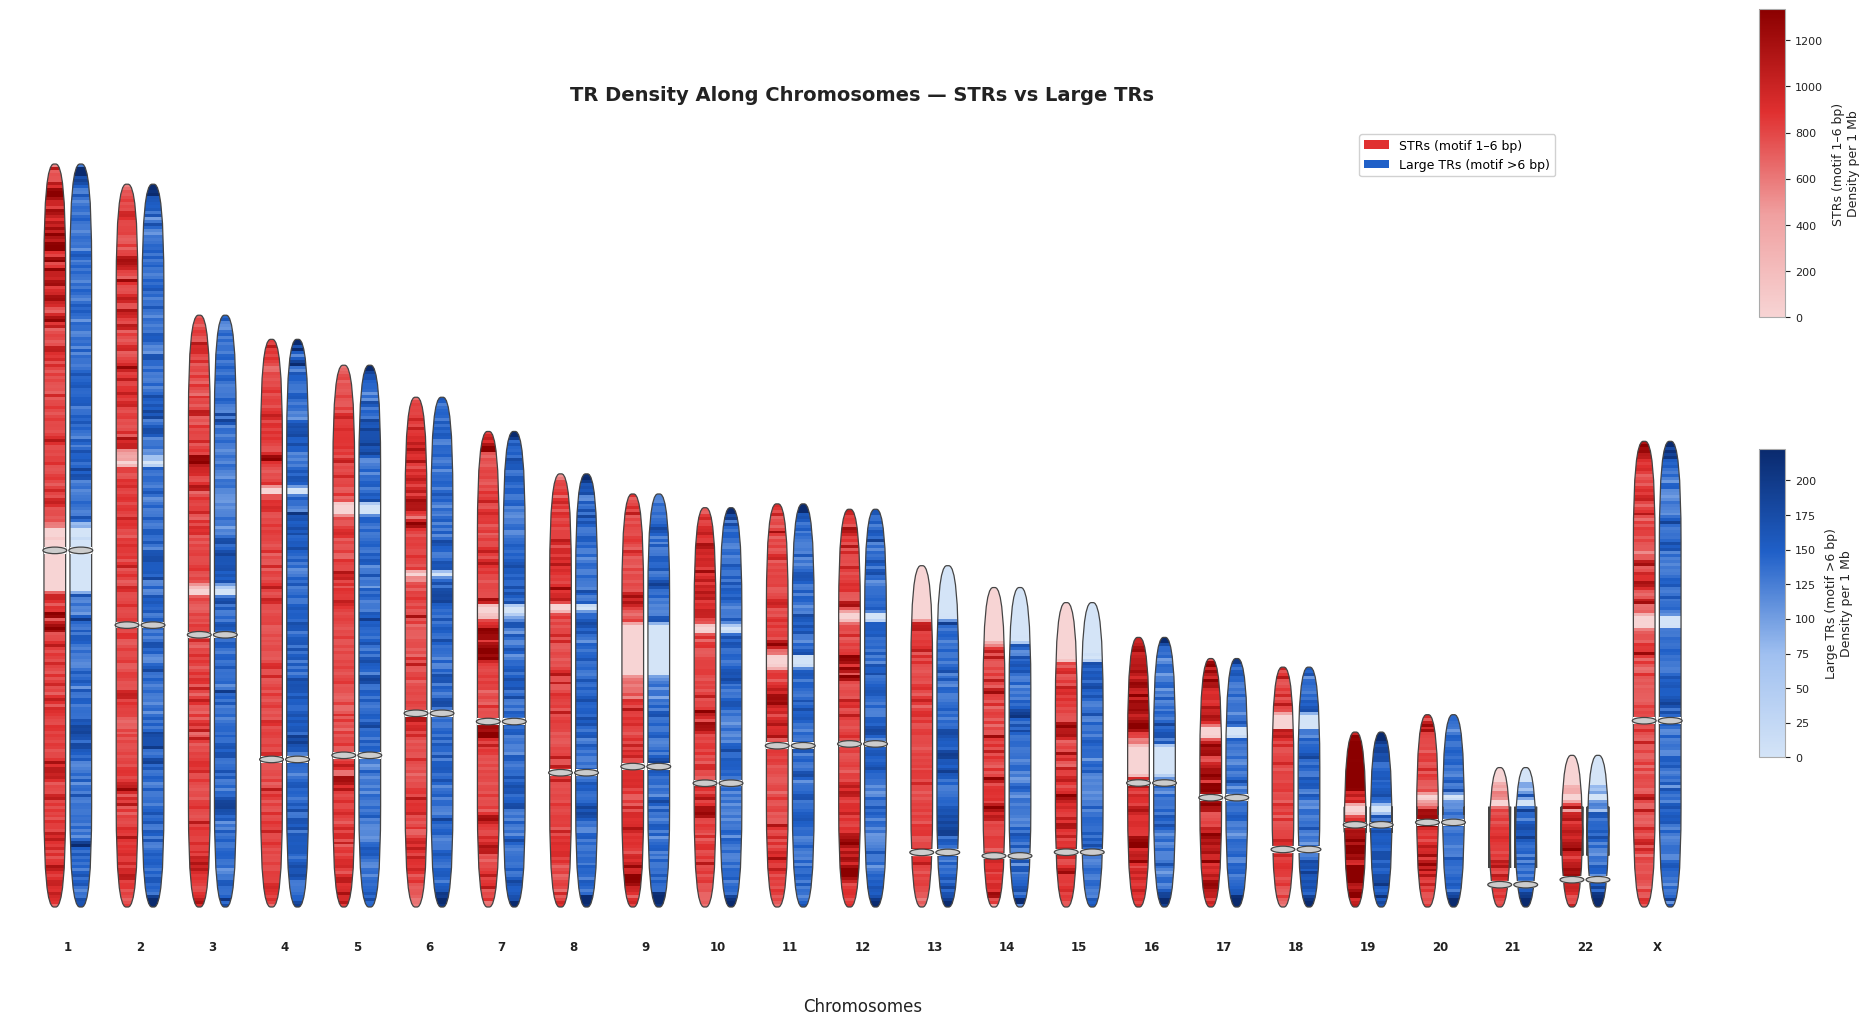

Saved: plot_chrom_ideogram_dual.png


In [ ]:
##3 ══════════════════════════════════════════════════════════════════
# PLOT 4 – TR distribution by Motif Size along the genome 
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path
import matplotlib.patheffects as pe

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

# ── Colormaps ─────────────────────────────────────────────────────
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red",  ["#f7d4d4", "#f0a0a0", "#e03030", "#8b0000"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#d4e4f7", "#a0c0f0", "#2060c8", "#0a2a6e"]
)

# Approximate centromere positions as fraction from bottom (p/q boundary)
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def rounded_chrom_path(x_center, bar_width, bar_h):
    """Create a rounded rectangle Path for clipping."""
    r  = bar_width * 0.45
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    y0, y1 = 0.0, bar_h

    # Approximate rounded rect with bezier corners
    verts = [
        (x0 + r, y0),
        (x1 - r, y0),
        (x1,     y0),
        (x1,     y0 + r),
        (x1,     y1 - r),
        (x1,     y1),
        (x1 - r, y1),
        (x0 + r, y1),
        (x0,     y1),
        (x0,     y1 - r),
        (x0,     y0 + r),
        (x0,     y0),
        (x0 + r, y0),
    ]
    codes = [
        Path.MOVETO,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
        Path.LINETO,
        Path.CURVE3,
        Path.CURVE3,
    ]
    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    """Draw one chromosome ideogram with density windows clipped inside."""
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    # ── Background fill ───────────────────────────────────────────
    bg = mpatches.FancyBboxPatch(
        (x_center - bar_width / 2, 0), bar_width, bar_h,
        boxstyle=f"round,pad=0,rounding_size={bar_width * 0.45}",
        linewidth=0, facecolor=bg_color, zorder=1
    )
    ax.add_patch(bg)

    # ── Clip path for density windows ────────────────────────────
    clip_path = rounded_chrom_path(x_center, bar_width, bar_h)
    clip_patch = mpatches.PathPatch(clip_path, transform=ax.transData,
                                    visible=False)
    ax.add_patch(clip_patch)

    # ── Density windows ───────────────────────────────────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Chromosome outline ────────────────────────────────────────
    outline = mpatches.FancyBboxPatch(
        (x_center - bar_width / 2, 0), bar_width, bar_h,
        boxstyle=f"round,pad=0,rounding_size={bar_width * 0.45}",
        linewidth=0.9, edgecolor="#444444",
        facecolor="none", zorder=7
    )
    ax.add_patch(outline)

    # ── Centromere ────────────────────────────────────────────────
    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac
    centro_h = win_h * 2.2

    # White gap + grey constriction
    for patch in [
        plt.Rectangle((x_center - bar_width / 2, centro_y - centro_h / 2),
                       bar_width, centro_h,
                       linewidth=0, facecolor="white", zorder=8),
        mpatches.Ellipse((x_center, centro_y),
                         bar_width * 1.1, centro_h,
                         linewidth=0.9, edgecolor="#444444",
                         facecolor="#cccccc", zorder=9),
    ]:
        ax.add_patch(patch)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    # ── Split into STR (1-6) and large TR (>6) ───────────────────
    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str, all_large   = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))

        for subset, store, all_list in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos        = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _  = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            all_list.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    # ── Figure ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.30   # width of each chromosome bar
    GAP    = 1.0    # gap between chromosome pairs
    OFFSET = 0.18   # left/right offset within a pair

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]
        bar_h     = chrom_len / MAX_LEN

        # Left = STR (red), Right = large TR (blue)
        x_str   = x_pair - OFFSET
        x_large = x_pair + OFFSET

        draw_chrom(ax, x_str,   chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_large, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        # Chromosome number label
        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",   0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    # ── Legend ────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right",
              fontsize=9, framealpha=0.9, edgecolor="#ccc",
              bbox_to_anchor=(0.91, 0.99))

    # ── Axes ──────────────────────────────────────────────────────
    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

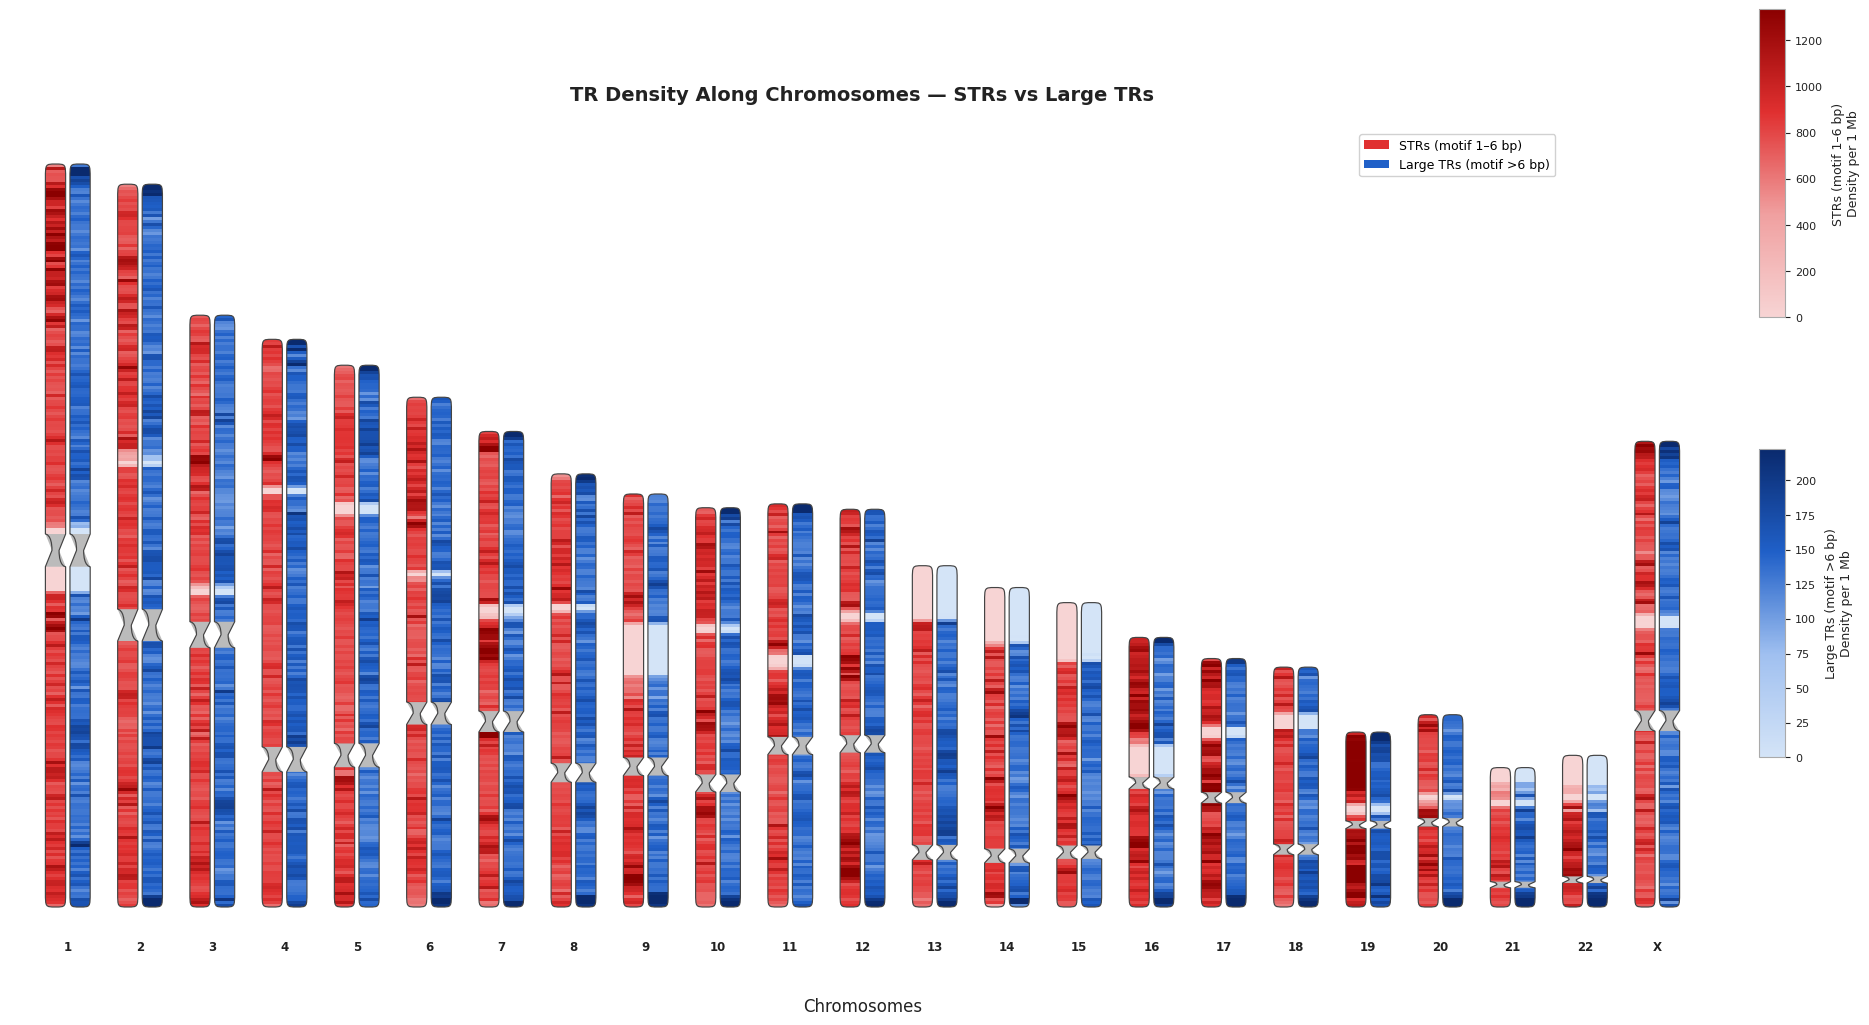

Saved: plot_chrom_ideogram_dual.png


In [ ]:
##3 ══════════════════════════════════════════════════════════════════
# PLOT 4 – TR distribution by Motif Size along the genome 
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red",  ["#f7d4d4", "#f0a0a0", "#e03030", "#8b0000"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#d4e4f7", "#a0c0f0", "#2060c8", "#0a2a6e"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, pinch_frac=0.35, cap_r_frac=0.07):
    """
    Chromosome outline with:
    - Slightly rounded end caps (small radius)
    - Hourglass constriction at centromere: both arms pinch inward
      and cross at the centromere midpoint, then flare back out
    """
    x0  = x_center - bar_width / 2
    x1  = x_center + bar_width / 2
    xm  = x_center
    r   = bar_width * cap_r_frac          # small cap radius
    px  = bar_width * pinch_frac / 2      # how far each side pinches inward

    ch  = bar_h * 0.022                   # centromere half-band height
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):           verts.append(p);              codes.append(Path.MOVETO)
    def L(p):           verts.append(p);              codes.append(Path.LINETO)
    def C(c1, c2, p):   verts.extend([c1, c2, p]);    codes.extend([Path.CURVE4]*3)

    # Start: bottom-left, just above the cap
    M((x0, r))

    # Bottom cap — slightly rounded
    C((x0, 0), (x0, 0), (xm, 0))          # left side of cap
    C((x1, 0), (x1, 0), (x1, r))          # right side of cap

    # Right arm — straight up to centromere bottom
    L((x1, cy_lo))

    # Right arm pinches inward toward centromere center
    C((x1, cy_lo), (xm + px, cy_lo), (xm + px, centro_y))
    # Then flares back out above centromere
    C((xm + px, centro_y), (x1, cy_hi), (x1, cy_hi))

    # Right arm continues to top
    L((x1, bar_h - r))

    # Top cap — slightly rounded
    C((x1, bar_h), (x1, bar_h), (xm, bar_h))
    C((x0, bar_h), (x0, bar_h), (x0, bar_h - r))

    # Left arm — straight down to centromere top
    L((x0, cy_hi))

    # Left arm pinches inward
    C((x0, cy_hi), (xm - px, cy_hi), (xm - px, centro_y))
    # Flares back below centromere
    C((xm - px, centro_y), (x0, cy_lo), (x0, cy_lo))

    # Back to start
    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill (hourglass region) ───────────────────
    ch    = bar_h * 0.022
    px    = bar_width * 0.35 / 2
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    centro_verts = [
        (x0,       cy_lo),                          # bottom-left
        (xm - px,  centro_y),                       # left pinch center
        (x0,       cy_hi),                          # top-left
        (x1,       cy_hi),                          # top-right
        (xm + px,  centro_y),                       # right pinch center
        (x1,       cy_lo),                          # bottom-right
        (x0,       cy_lo),                          # close
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#bbbbbb", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

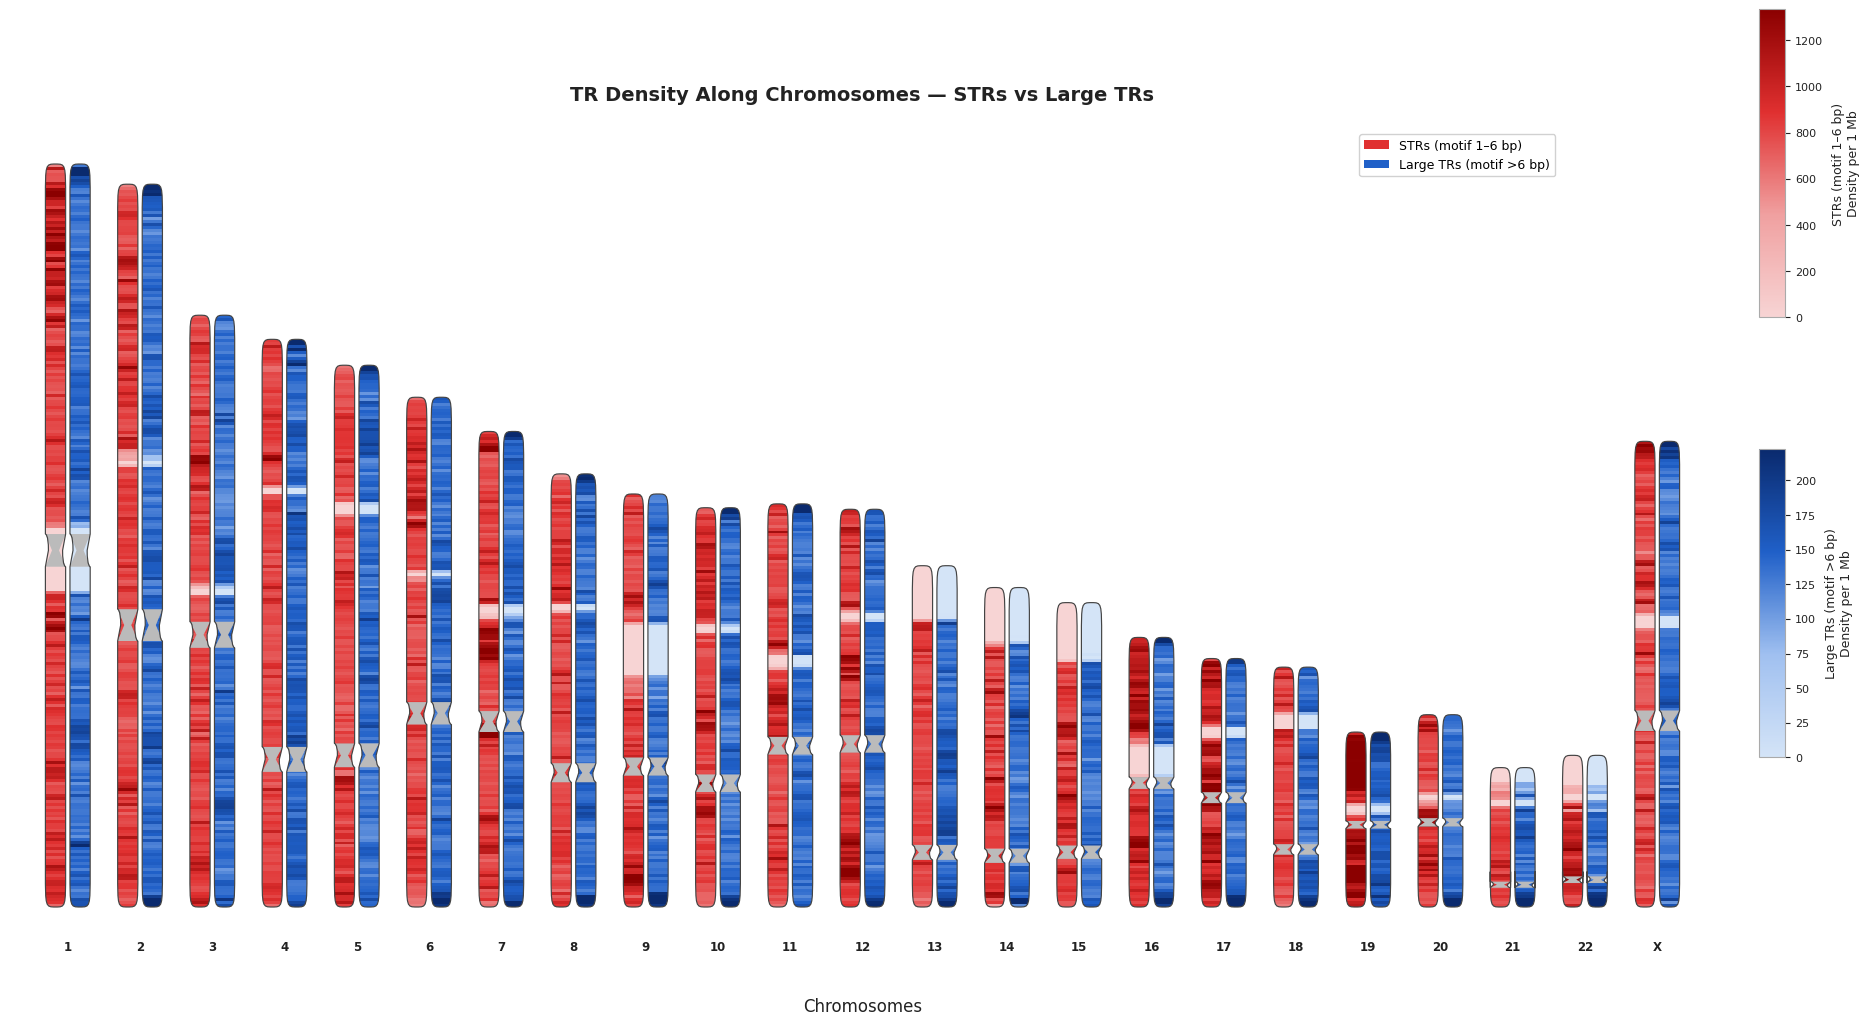

Saved: plot_chrom_ideogram_dual.png


In [ ]:
##3 ══════════════════════════════════════════════════════════════════
# PLOT 4 – TR distribution by Motif Size along the genome 
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red",  ["#f7d4d4", "#f0a0a0", "#e03030", "#8b0000"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#d4e4f7", "#a0c0f0", "#2060c8", "#0a2a6e"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, pinch_frac=0.7, cap_r_frac=0.17):
    """
    Chromosome outline with:
    - Slightly rounded end caps (small radius)
    - Hourglass constriction at centromere: both arms pinch inward
      and cross at the centromere midpoint, then flare back out
    """
    x0  = x_center - bar_width / 2
    x1  = x_center + bar_width / 2
    xm  = x_center
    r   = bar_width * cap_r_frac          # small cap radius
    px  = bar_width * pinch_frac / 2      # how far each side pinches inward

    ch  = bar_h * 0.022                   # centromere half-band height
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):           verts.append(p);              codes.append(Path.MOVETO)
    def L(p):           verts.append(p);              codes.append(Path.LINETO)
    def C(c1, c2, p):   verts.extend([c1, c2, p]);    codes.extend([Path.CURVE4]*3)

    # Start: bottom-left, just above the cap
    M((x0, r))

    # Bottom cap — slightly rounded
    C((x0, 0), (x0, 0), (xm, 0))          # left side of cap
    C((x1, 0), (x1, 0), (x1, r))          # right side of cap

    # Right arm — straight up to centromere bottom
    L((x1, cy_lo))

    # Right arm pinches inward toward centromere center
    C((x1, cy_lo), (xm + px, cy_lo), (xm + px, centro_y))
    # Then flares back out above centromere
    C((xm + px, centro_y), (x1, cy_hi), (x1, cy_hi))

    # Right arm continues to top
    L((x1, bar_h - r))

    # Top cap — slightly rounded
    C((x1, bar_h), (x1, bar_h), (xm, bar_h))
    C((x0, bar_h), (x0, bar_h), (x0, bar_h - r))

    # Left arm — straight down to centromere top
    L((x0, cy_hi))

    # Left arm pinches inward
    C((x0, cy_hi), (xm - px, cy_hi), (xm - px, centro_y))
    # Flares back below centromere
    C((xm - px, centro_y), (x0, cy_lo), (x0, cy_lo))

    # Back to start
    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill (hourglass region) ───────────────────
    ch    = bar_h * 0.022
    px    = bar_width * 0.35 / 2
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    centro_verts = [
        (x0,       cy_lo),                          # bottom-left
        (xm - px,  centro_y),                       # left pinch center
        (x0,       cy_hi),                          # top-left
        (x1,       cy_hi),                          # top-right
        (xm + px,  centro_y),                       # right pinch center
        (x1,       cy_lo),                          # bottom-right
        (x0,       cy_lo),                          # close
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#bbbbbb", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

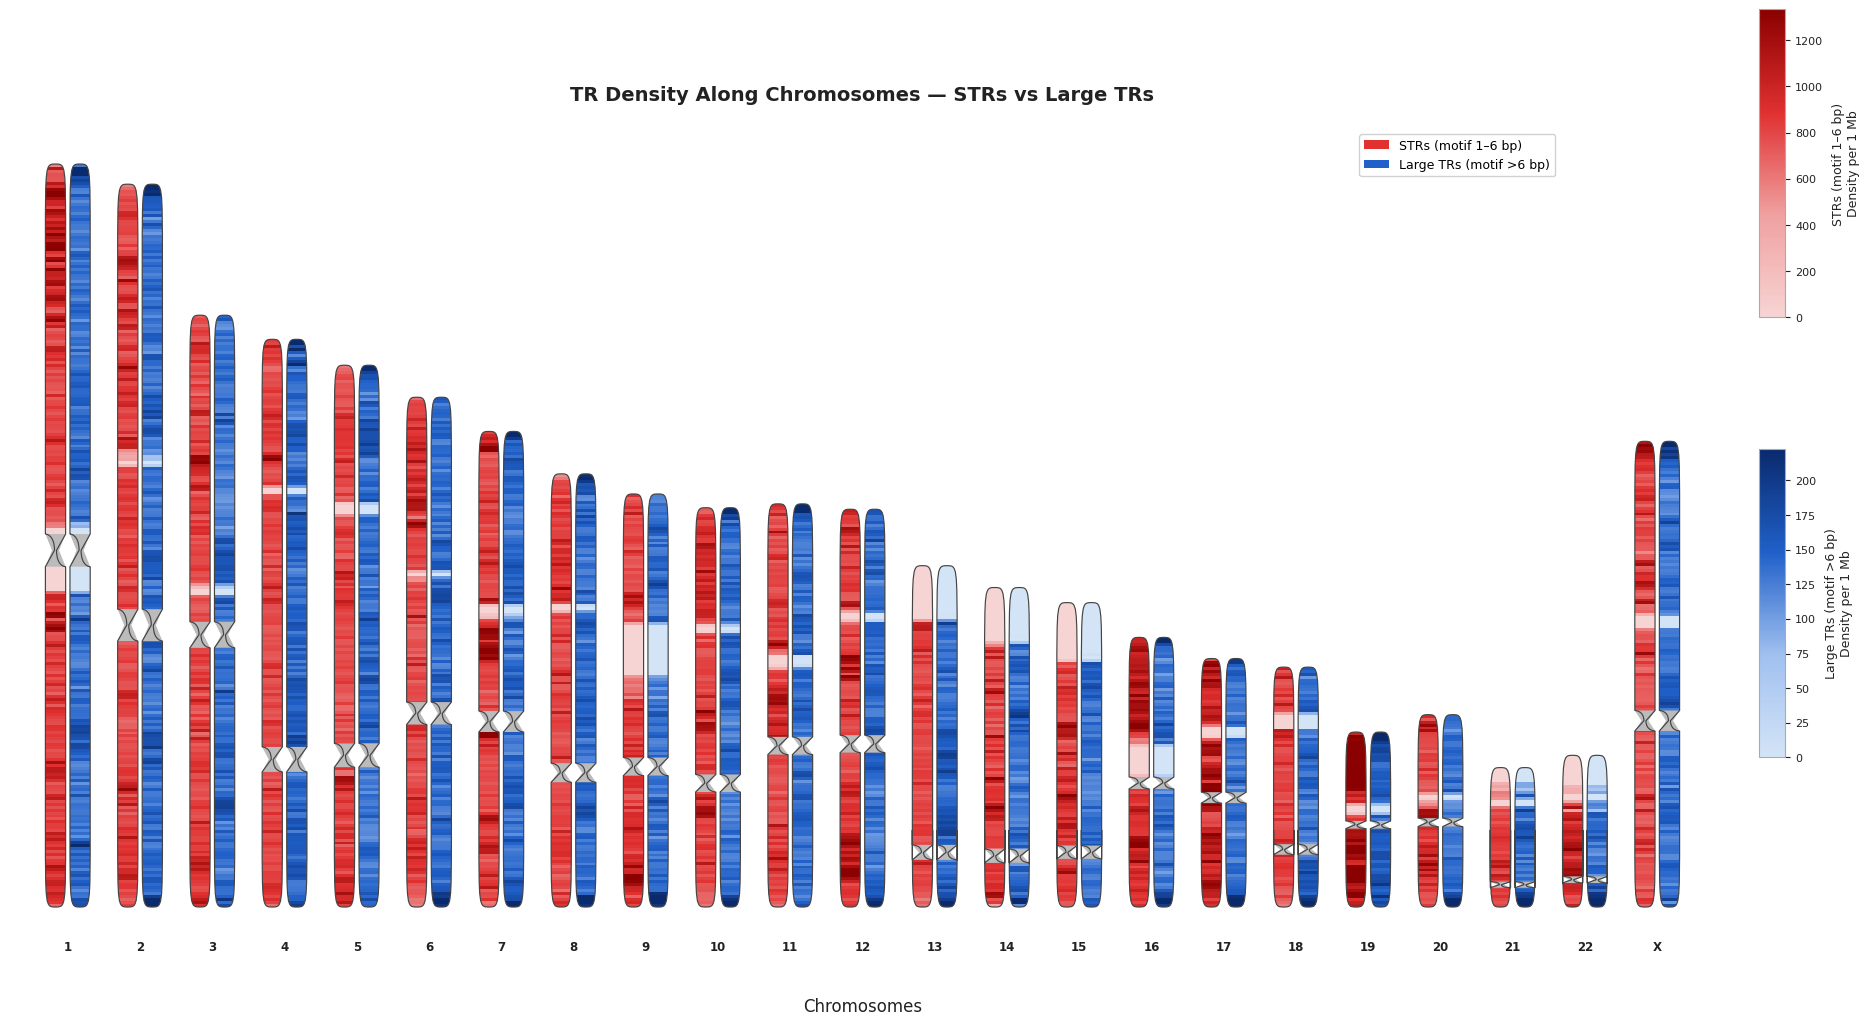

Saved: plot_chrom_ideogram_dual.png


In [ ]:
##3 ══════════════════════════════════════════════════════════════════
# PLOT 4 – TR distribution by Motif Size along the genome 
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red",  ["#f7d4d4", "#f0a0a0", "#e03030", "#8b0000"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#d4e4f7", "#a0c0f0", "#2060c8", "#0a2a6e"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, pinch_frac=0.1, cap_r_frac=0.37):
    """
    Chromosome outline with:
    - Slightly rounded end caps (small radius)
    - Hourglass constriction at centromere: both arms pinch inward
      and cross at the centromere midpoint, then flare back out
    """
    x0  = x_center - bar_width / 2
    x1  = x_center + bar_width / 2
    xm  = x_center
    r   = bar_width * cap_r_frac          # small cap radius
    px  = bar_width * pinch_frac / 2      # how far each side pinches inward

    ch  = bar_h * 0.022                   # centromere half-band height
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):           verts.append(p);              codes.append(Path.MOVETO)
    def L(p):           verts.append(p);              codes.append(Path.LINETO)
    def C(c1, c2, p):   verts.extend([c1, c2, p]);    codes.extend([Path.CURVE4]*3)

    # Start: bottom-left, just above the cap
    M((x0, r))

    # Bottom cap — slightly rounded
    C((x0, 0), (x0, 0), (xm, 0))          # left side of cap
    C((x1, 0), (x1, 0), (x1, r))          # right side of cap

    # Right arm — straight up to centromere bottom
    L((x1, cy_lo))

    # Right arm pinches inward toward centromere center
    C((x1, cy_lo), (xm + px, cy_lo), (xm + px, centro_y))
    # Then flares back out above centromere
    C((xm + px, centro_y), (x1, cy_hi), (x1, cy_hi))

    # Right arm continues to top
    L((x1, bar_h - r))

    # Top cap — slightly rounded
    C((x1, bar_h), (x1, bar_h), (xm, bar_h))
    C((x0, bar_h), (x0, bar_h), (x0, bar_h - r))

    # Left arm — straight down to centromere top
    L((x0, cy_hi))

    # Left arm pinches inward
    C((x0, cy_hi), (xm - px, cy_hi), (xm - px, centro_y))
    # Flares back below centromere
    C((xm - px, centro_y), (x0, cy_lo), (x0, cy_lo))

    # Back to start
    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill (hourglass region) ───────────────────
    ch    = bar_h * 0.022
    px    = bar_width * 0.35 / 2
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    centro_verts = [
        (x0,       cy_lo),                          # bottom-left
        (xm - px,  centro_y),                       # left pinch center
        (x0,       cy_hi),                          # top-left
        (x1,       cy_hi),                          # top-right
        (xm + px,  centro_y),                       # right pinch center
        (x1,       cy_lo),                          # bottom-right
        (x0,       cy_lo),                          # close
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#bbbbbb", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

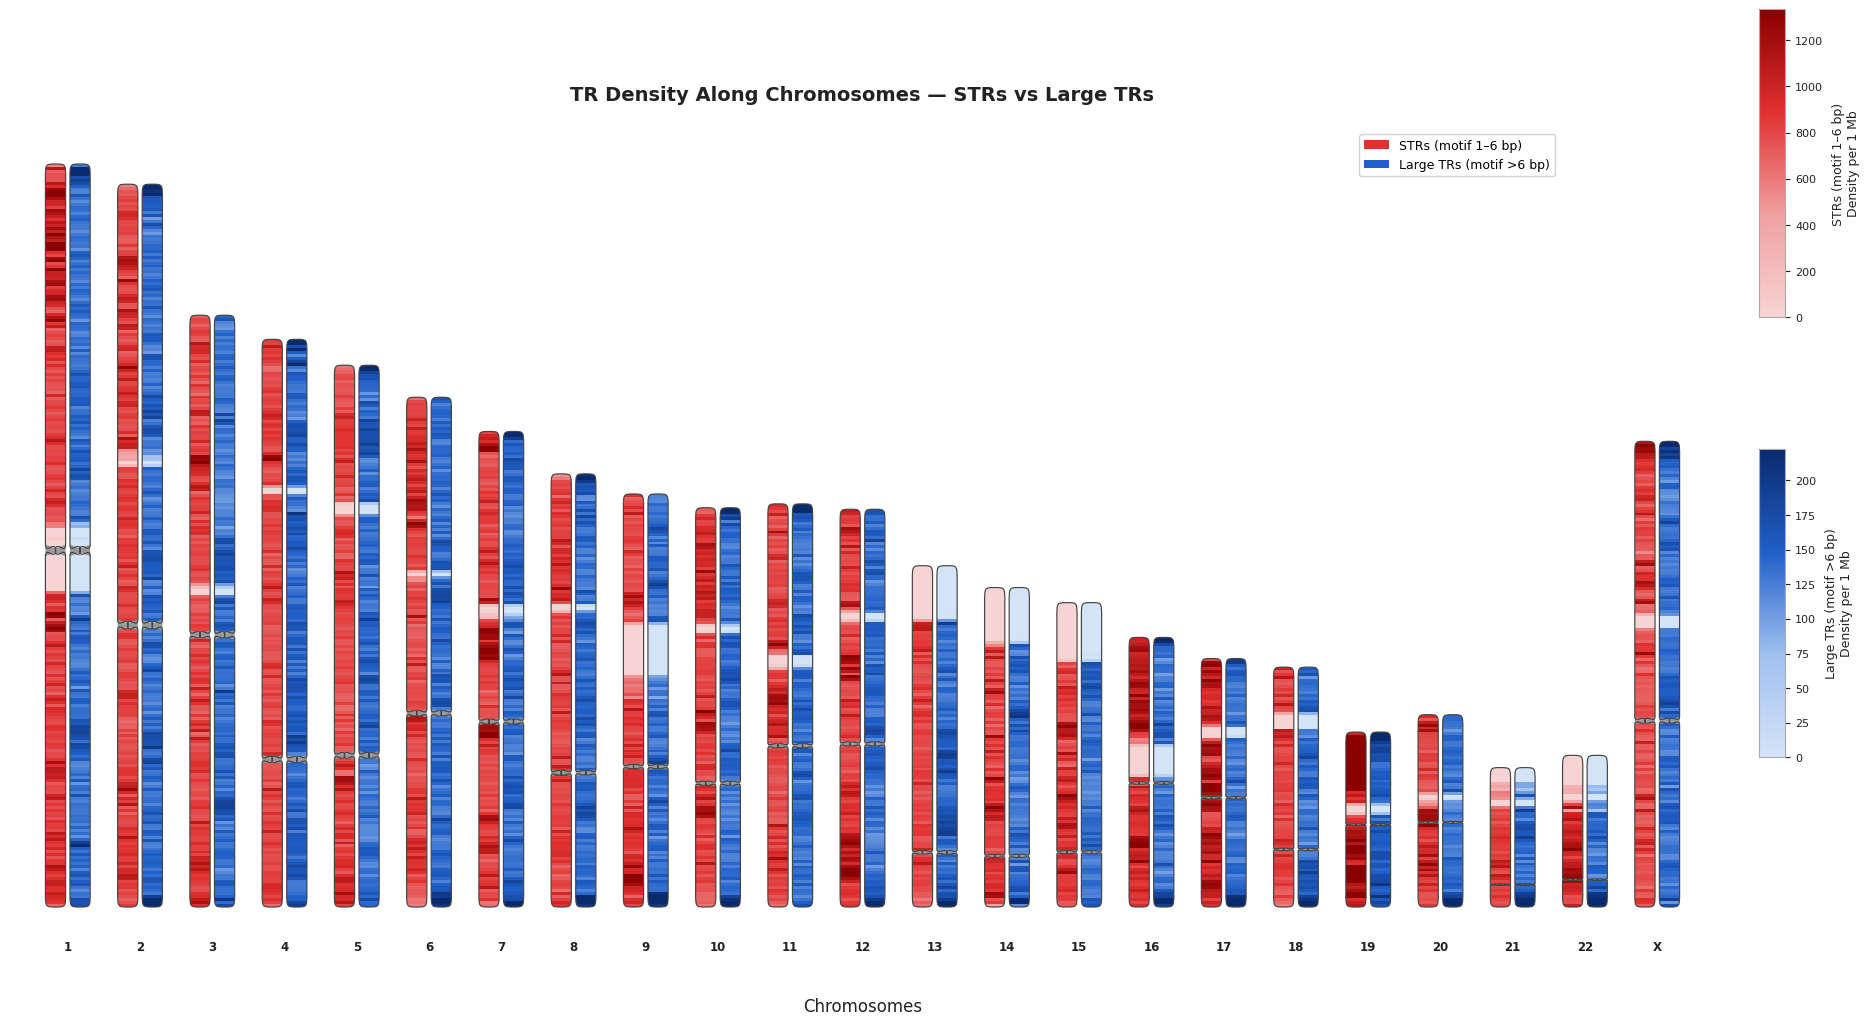

Saved: plot_chrom_ideogram_dual.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red",  ["#f7d4d4", "#f0a0a0", "#e03030", "#8b0000"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#d4e4f7", "#a0c0f0", "#2060c8", "#0a2a6e"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, cap_r_frac=0.07):
    """
    Chromosome outline with:
    - Slightly rounded end caps
    - Tight X-shaped twist at centromere: the two edges cross over each
      other at a single point (xm, centro_y), creating a sharp pinch
      with very short transition zone (ch very small).
    """
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    xm = x_center
    r  = bar_width * cap_r_frac

    # Very short transition — tight twist, not a wide hourglass
    ch = bar_h * 0.008          # half-height of constriction zone (very tight)
    t  = bar_h * 0.014          # bezier pull distance above/below crossing

    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):         verts.append(p);           codes.append(Path.MOVETO)
    def L(p):         verts.append(p);           codes.append(Path.LINETO)
    def C(c1, c2, p): verts.extend([c1, c2, p]); codes.extend([Path.CURVE4]*3)

    # ── Bottom cap ────────────────────────────────────────────────
    M((x0, r))
    C((x0, 0), (x0, 0), (xm, 0))
    C((x1, 0), (x1, 0), (x1, r))

    # Right edge straight up to just below crossing
    L((x1, cy_lo))

    # Right edge curves sharply inward, crosses to left at centro_y,
    # then curves back out to right above centro
    C((x1, cy_lo + t), (xm, centro_y - t), (xm, centro_y))   # cross to center
    C((xm, centro_y + t), (x0, cy_hi - t), (x0, cy_hi))      # emerge left side → right

    # Continue up right side from cy_hi back to x1
    # (the "twist": right edge emerges on the left then snaps back)
    # We draw the RIGHT outline going to top after crossing:
    L((x0, bar_h - r))

    # ── Top cap ───────────────────────────────────────────────────
    C((x0, bar_h), (x0, bar_h), (xm, bar_h))
    C((x1, bar_h), (x1, bar_h), (x1, bar_h - r))

    # Left edge down from top to just above crossing
    L((x1, cy_hi))

    # Left edge mirrors the twist
    C((x1, cy_hi - t), (xm, centro_y + t), (xm, centro_y))
    C((xm, centro_y - t), (x0, cy_lo + t), (x0, cy_lo))

    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill — tight X twist ─────────────────────
    ch    = bar_h * 0.008
    t     = bar_h * 0.014
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    # Fill just the tiny crossing zone as a slim diamond
    centro_verts = [
        (x0,  cy_lo),
        (xm,  centro_y - ch * 0.3),
        (x1,  cy_lo),
        (x1,  cy_hi),
        (xm,  centro_y + ch * 0.3),
        (x0,  cy_hi),
        (x0,  cy_lo),
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#999999", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

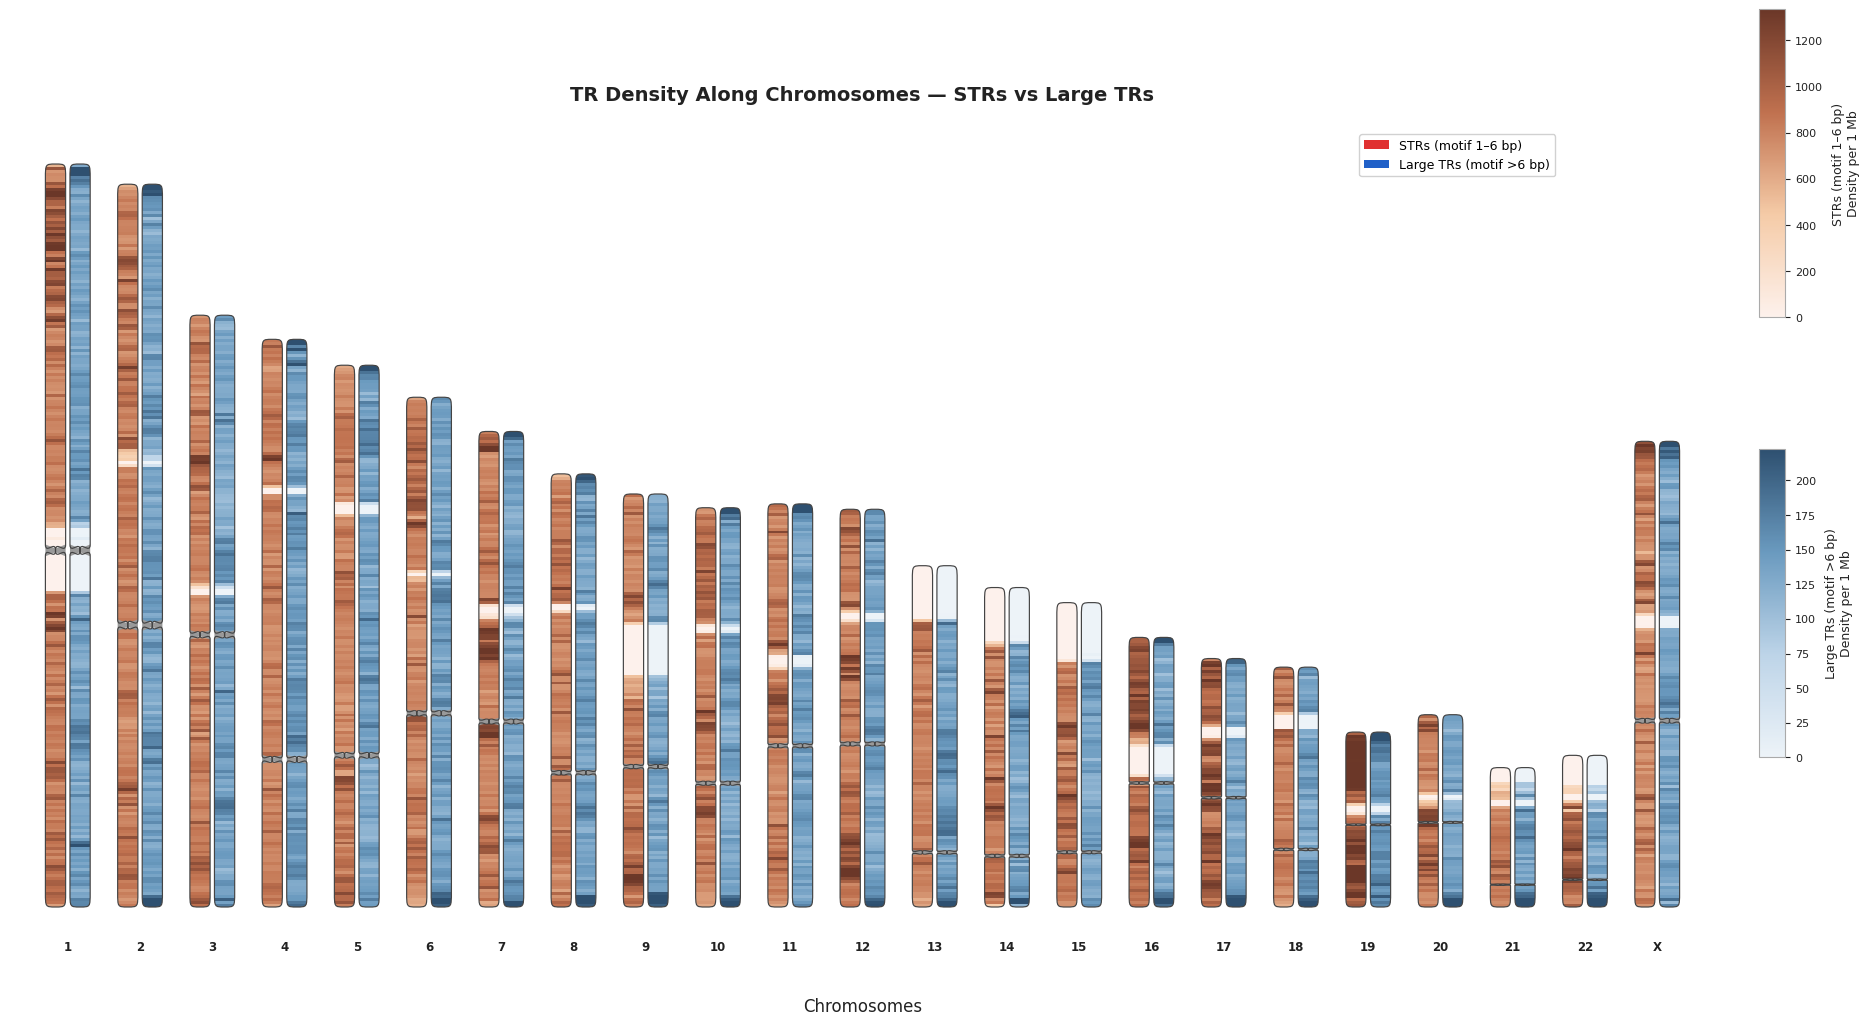

Saved: plot_chrom_ideogram_dual.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

# Pale peach → soft amber → burnt sienna
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red", ["#fdf1ec", "#f5cba7", "#c0714f", "#6b3728"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#edf3f8", "#bdd4e8", "#6a9abf", "#2e5070"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, cap_r_frac=0.07):
    """
    Chromosome outline with:
    - Slightly rounded end caps
    - Tight X-shaped twist at centromere: the two edges cross over each
      other at a single point (xm, centro_y), creating a sharp pinch
      with very short transition zone (ch very small).
    """
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    xm = x_center
    r  = bar_width * cap_r_frac

    # Very short transition — tight twist, not a wide hourglass
    ch = bar_h * 0.008          # half-height of constriction zone (very tight)
    t  = bar_h * 0.014          # bezier pull distance above/below crossing

    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):         verts.append(p);           codes.append(Path.MOVETO)
    def L(p):         verts.append(p);           codes.append(Path.LINETO)
    def C(c1, c2, p): verts.extend([c1, c2, p]); codes.extend([Path.CURVE4]*3)

    # ── Bottom cap ────────────────────────────────────────────────
    M((x0, r))
    C((x0, 0), (x0, 0), (xm, 0))
    C((x1, 0), (x1, 0), (x1, r))

    # Right edge straight up to just below crossing
    L((x1, cy_lo))

    # Right edge curves sharply inward, crosses to left at centro_y,
    # then curves back out to right above centro
    C((x1, cy_lo + t), (xm, centro_y - t), (xm, centro_y))   # cross to center
    C((xm, centro_y + t), (x0, cy_hi - t), (x0, cy_hi))      # emerge left side → right

    # Continue up right side from cy_hi back to x1
    # (the "twist": right edge emerges on the left then snaps back)
    # We draw the RIGHT outline going to top after crossing:
    L((x0, bar_h - r))

    # ── Top cap ───────────────────────────────────────────────────
    C((x0, bar_h), (x0, bar_h), (xm, bar_h))
    C((x1, bar_h), (x1, bar_h), (x1, bar_h - r))

    # Left edge down from top to just above crossing
    L((x1, cy_hi))

    # Left edge mirrors the twist
    C((x1, cy_hi - t), (xm, centro_y + t), (xm, centro_y))
    C((xm, centro_y - t), (x0, cy_lo + t), (x0, cy_lo))

    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill — tight X twist ─────────────────────
    ch    = bar_h * 0.008
    t     = bar_h * 0.014
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    # Fill just the tiny crossing zone as a slim diamond
    centro_verts = [
        (x0,  cy_lo),
        (xm,  centro_y - ch * 0.3),
        (x1,  cy_lo),
        (x1,  cy_hi),
        (xm,  centro_y + ch * 0.3),
        (x0,  cy_hi),
        (x0,  cy_lo),
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#999999", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

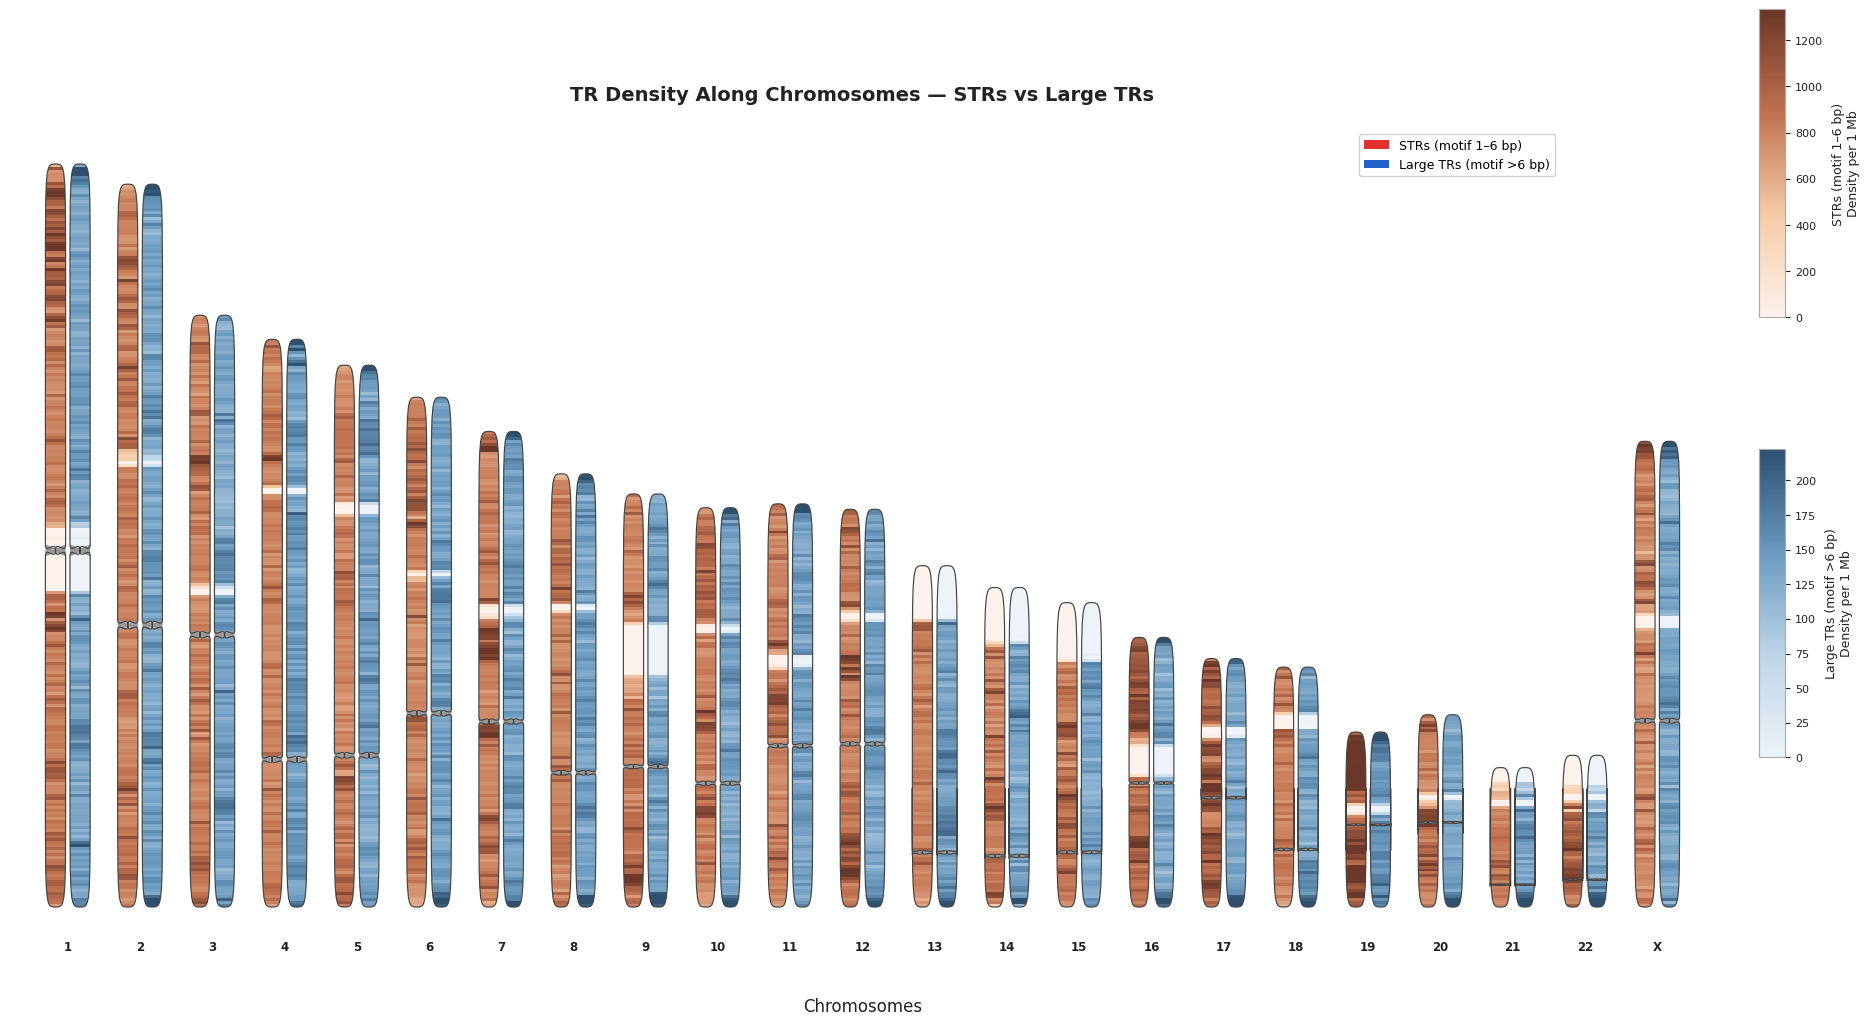

Saved: plot_chrom_ideogram_dual.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

# Pale peach → soft amber → burnt sienna
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red", ["#fdf1ec", "#f5cba7", "#c0714f", "#6b3728"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#edf3f8", "#bdd4e8", "#6a9abf", "#2e5070"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, cap_r_frac=0.57):
    """
    Chromosome outline with:
    - Slightly rounded end caps
    - Tight X-shaped twist at centromere: the two edges cross over each
      other at a single point (xm, centro_y), creating a sharp pinch
      with very short transition zone (ch very small).
    """
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    xm = x_center
    r  = bar_width * cap_r_frac

    # Very short transition — tight twist, not a wide hourglass
    ch = bar_h * 0.008          # half-height of constriction zone (very tight)
    t  = bar_h * 0.014          # bezier pull distance above/below crossing

    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):         verts.append(p);           codes.append(Path.MOVETO)
    def L(p):         verts.append(p);           codes.append(Path.LINETO)
    def C(c1, c2, p): verts.extend([c1, c2, p]); codes.extend([Path.CURVE4]*3)

    # ── Bottom cap ────────────────────────────────────────────────
    M((x0, r))
    C((x0, 0), (x0, 0), (xm, 0))
    C((x1, 0), (x1, 0), (x1, r))

    # Right edge straight up to just below crossing
    L((x1, cy_lo))

    # Right edge curves sharply inward, crosses to left at centro_y,
    # then curves back out to right above centro
    C((x1, cy_lo + t), (xm, centro_y - t), (xm, centro_y))   # cross to center
    C((xm, centro_y + t), (x0, cy_hi - t), (x0, cy_hi))      # emerge left side → right

    # Continue up right side from cy_hi back to x1
    # (the "twist": right edge emerges on the left then snaps back)
    # We draw the RIGHT outline going to top after crossing:
    L((x0, bar_h - r))

    # ── Top cap ───────────────────────────────────────────────────
    C((x0, bar_h), (x0, bar_h), (xm, bar_h))
    C((x1, bar_h), (x1, bar_h), (x1, bar_h - r))

    # Left edge down from top to just above crossing
    L((x1, cy_hi))

    # Left edge mirrors the twist
    C((x1, cy_hi - t), (xm, centro_y + t), (xm, centro_y))
    C((xm, centro_y - t), (x0, cy_lo + t), (x0, cy_lo))

    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill — tight X twist ─────────────────────
    ch    = bar_h * 0.008
    t     = bar_h * 0.014
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    # Fill just the tiny crossing zone as a slim diamond
    centro_verts = [
        (x0,  cy_lo),
        (xm,  centro_y - ch * 0.3),
        (x1,  cy_lo),
        (x1,  cy_hi),
        (xm,  centro_y + ch * 0.3),
        (x0,  cy_hi),
        (x0,  cy_lo),
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#999999", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

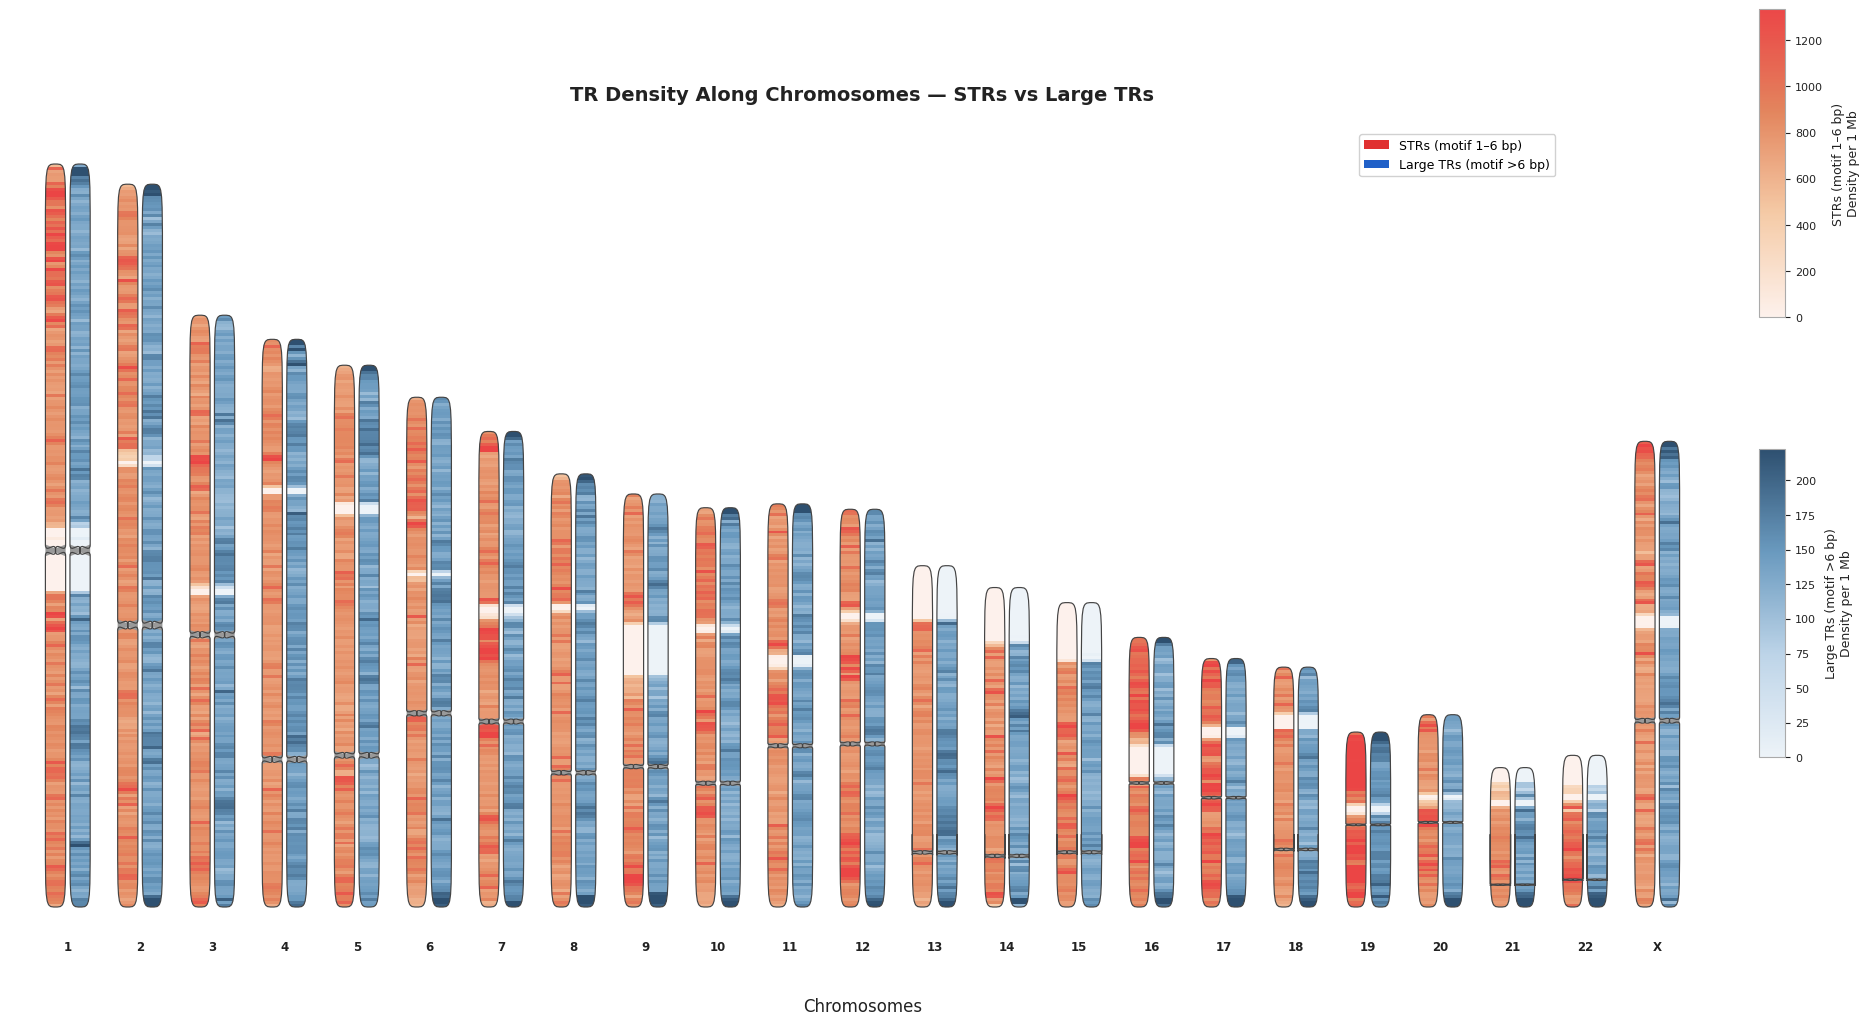

Saved: plot_chrom_ideogram_dual.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

# Pale peach → soft amber → burnt sienna
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red", ["#fdf1ec", "#f5cba7", "#e3865e", "#e93131e3"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#edf3f8", "#bdd4e8", "#6a9abf", "#2e5070"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, cap_r_frac=0.35):
    """
    Chromosome outline with:
    - Slightly rounded end caps
    - Tight X-shaped twist at centromere: the two edges cross over each
      other at a single point (xm, centro_y), creating a sharp pinch
      with very short transition zone (ch very small).
    """
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    xm = x_center
    r  = bar_width * cap_r_frac

    # Very short transition — tight twist, not a wide hourglass
    ch = bar_h * 0.008          # half-height of constriction zone (very tight)
    t  = bar_h * 0.014          # bezier pull distance above/below crossing

    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):         verts.append(p);           codes.append(Path.MOVETO)
    def L(p):         verts.append(p);           codes.append(Path.LINETO)
    def C(c1, c2, p): verts.extend([c1, c2, p]); codes.extend([Path.CURVE4]*3)

    # ── Bottom cap ────────────────────────────────────────────────
    M((x0, r))
    C((x0, 0), (x0, 0), (xm, 0))
    C((x1, 0), (x1, 0), (x1, r))

    # Right edge straight up to just below crossing
    L((x1, cy_lo))

    # Right edge curves sharply inward, crosses to left at centro_y,
    # then curves back out to right above centro
    C((x1, cy_lo + t), (xm, centro_y - t), (xm, centro_y))   # cross to center
    C((xm, centro_y + t), (x0, cy_hi - t), (x0, cy_hi))      # emerge left side → right

    # Continue up right side from cy_hi back to x1
    # (the "twist": right edge emerges on the left then snaps back)
    # We draw the RIGHT outline going to top after crossing:
    L((x0, bar_h - r))

    # ── Top cap ───────────────────────────────────────────────────
    C((x0, bar_h), (x0, bar_h), (xm, bar_h))
    C((x1, bar_h), (x1, bar_h), (x1, bar_h - r))

    # Left edge down from top to just above crossing
    L((x1, cy_hi))

    # Left edge mirrors the twist
    C((x1, cy_hi - t), (xm, centro_y + t), (xm, centro_y))
    C((xm, centro_y - t), (x0, cy_lo + t), (x0, cy_lo))

    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill — tight X twist ─────────────────────
    ch    = bar_h * 0.008
    t     = bar_h * 0.014
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    # Fill just the tiny crossing zone as a slim diamond
    centro_verts = [
        (x0,  cy_lo),
        (xm,  centro_y - ch * 0.3),
        (x1,  cy_lo),
        (x1,  cy_hi),
        (xm,  centro_y + ch * 0.3),
        (x0,  cy_hi),
        (x0,  cy_lo),
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#999999", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

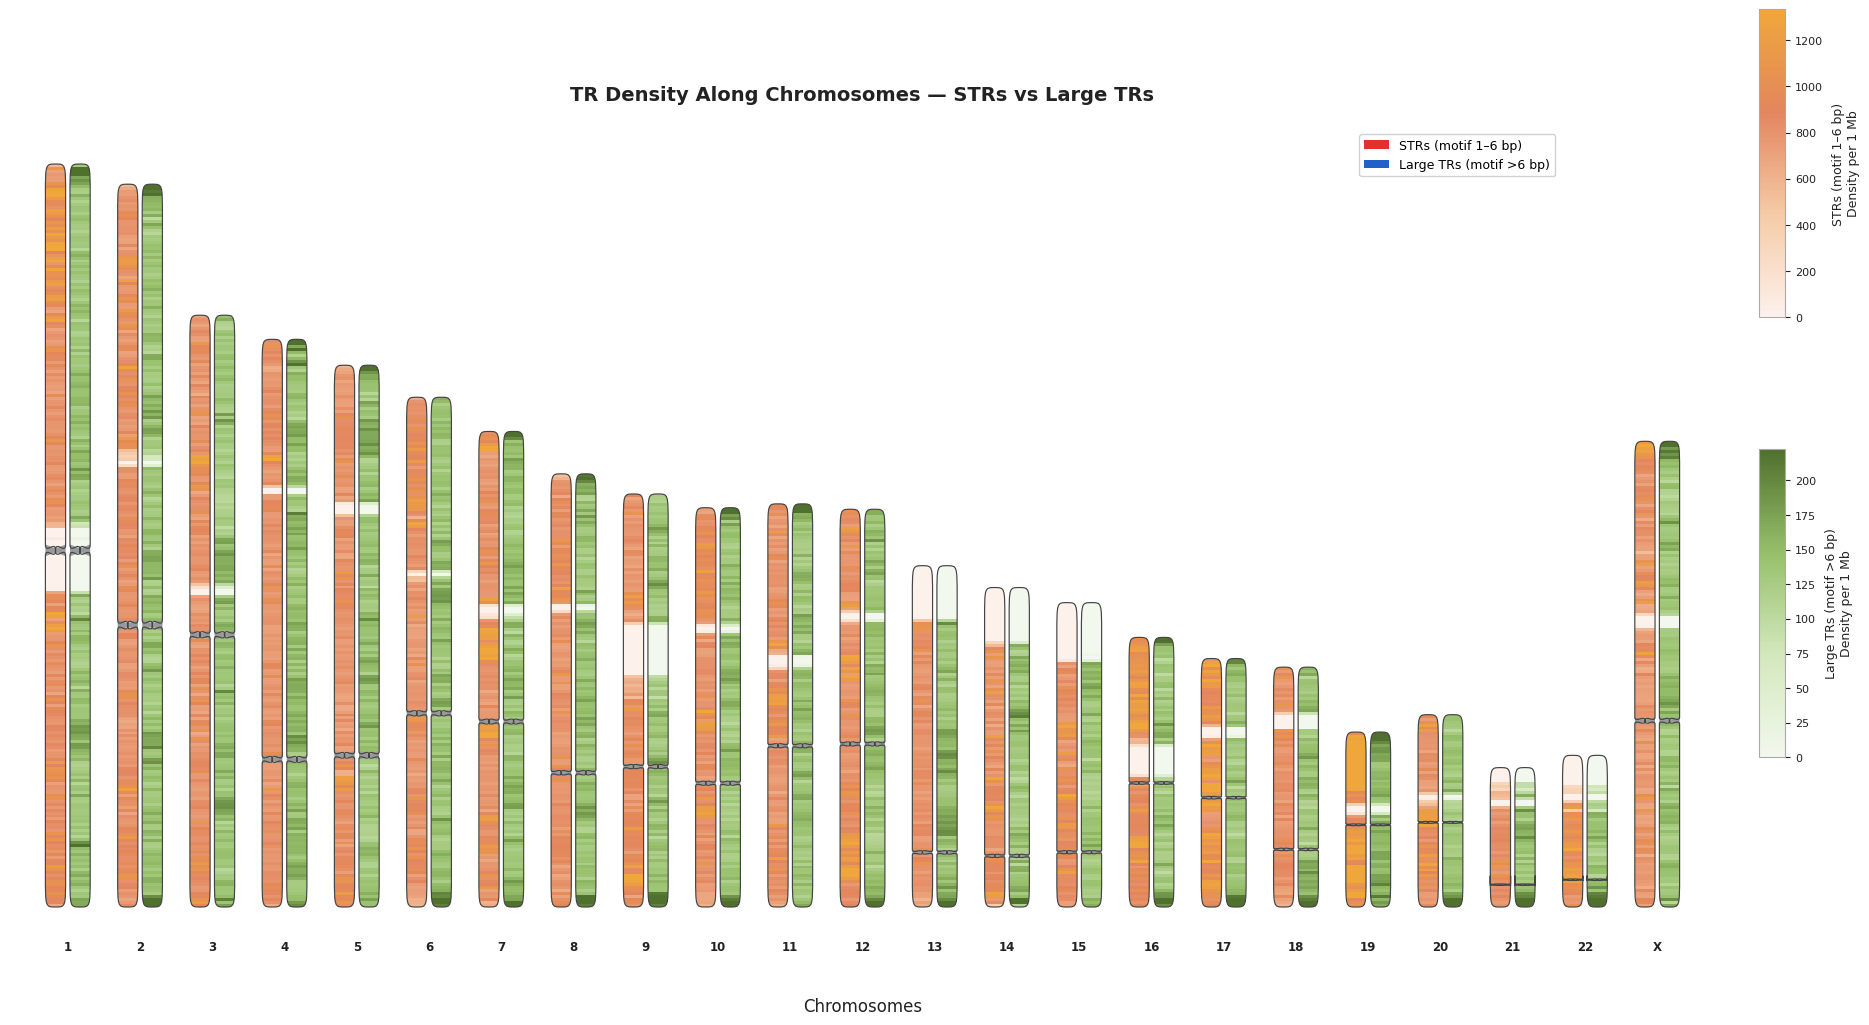

Saved: plot_chrom_ideogram_dual.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.path import Path

# ── Chromosome lengths (hg38) ─────────────────────────────────────
CHROM_LENGTHS = {
    "chr1":248956422,"chr2":242193529,"chr3":198295559,"chr4":190214555,
    "chr5":181538259,"chr6":170805979,"chr7":159345973,"chr8":145138636,
    "chr9":138394717,"chr10":133797422,"chr11":135086622,"chr12":133275309,
    "chr13":114364328,"chr14":107043718,"chr15":101991189,"chr16":90338345,
    "chr17":83257441, "chr18":80373285, "chr19":58617616, "chr20":64444167,
    "chr21":46709983, "chr22":50818468, "chrX":156040895,"chrY":57227415,
}

CHR_ORDER = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
MAX_LEN   = CHROM_LENGTHS["chr1"]
WIN_SIZE  = 1_000_000  # 1 Mb windows

# Pale peach → soft amber → burnt sienna
CMAP_RED = mcolors.LinearSegmentedColormap.from_list(
    "str_red", ["#fdf1ec", "#f5cba7", "#e3865e", "#efa73bff"]
)
CMAP_BLUE = mcolors.LinearSegmentedColormap.from_list(
    "str_blue", ["#f2f8ed", "#d3e8bd", "#96bf6a", "#50702e"]
)

# Centromere position as fraction from bottom
CENTROMERE_FRAC = {
    "chr1":0.48,"chr2":0.39,"chr3":0.46,"chr4":0.26,"chr5":0.28,
    "chr6":0.38,"chr7":0.39,"chr8":0.31,"chr9":0.34,"chr10":0.31,
    "chr11":0.40,"chr12":0.41,"chr13":0.16,"chr14":0.16,"chr15":0.18,
    "chr16":0.46,"chr17":0.44,"chr18":0.24,"chr19":0.47,"chr20":0.44,
    "chr21":0.16,"chr22":0.18,"chrX":0.40,"chrY":0.25,
}


def make_chrom_path(x_center, bar_width, bar_h, centro_y, cap_r_frac=0.15):
    """
    Chromosome outline with:
    - Slightly rounded end caps
    - Tight X-shaped twist at centromere: the two edges cross over each
      other at a single point (xm, centro_y), creating a sharp pinch
      with very short transition zone (ch very small).
    """
    x0 = x_center - bar_width / 2
    x1 = x_center + bar_width / 2
    xm = x_center
    r  = bar_width * cap_r_frac

    # Very short transition — tight twist, not a wide hourglass
    ch = bar_h * 0.008          # half-height of constriction zone (very tight)
    t  = bar_h * 0.014          # bezier pull distance above/below crossing

    cy_lo = centro_y - ch
    cy_hi = centro_y + ch

    verts = []
    codes = []

    def M(p):         verts.append(p);           codes.append(Path.MOVETO)
    def L(p):         verts.append(p);           codes.append(Path.LINETO)
    def C(c1, c2, p): verts.extend([c1, c2, p]); codes.extend([Path.CURVE4]*3)

    # ── Bottom cap ────────────────────────────────────────────────
    M((x0, r))
    C((x0, 0), (x0, 0), (xm, 0))
    C((x1, 0), (x1, 0), (x1, r))

    # Right edge straight up to just below crossing
    L((x1, cy_lo))

    # Right edge curves sharply inward, crosses to left at centro_y,
    # then curves back out to right above centro
    C((x1, cy_lo + t), (xm, centro_y - t), (xm, centro_y))   # cross to center
    C((xm, centro_y + t), (x0, cy_hi - t), (x0, cy_hi))      # emerge left side → right

    # Continue up right side from cy_hi back to x1
    # (the "twist": right edge emerges on the left then snaps back)
    # We draw the RIGHT outline going to top after crossing:
    L((x0, bar_h - r))

    # ── Top cap ───────────────────────────────────────────────────
    C((x0, bar_h), (x0, bar_h), (xm, bar_h))
    C((x1, bar_h), (x1, bar_h), (x1, bar_h - r))

    # Left edge down from top to just above crossing
    L((x1, cy_hi))

    # Left edge mirrors the twist
    C((x1, cy_hi - t), (xm, centro_y + t), (xm, centro_y))
    C((xm, centro_y - t), (x0, cy_lo + t), (x0, cy_lo))

    L((x0, r))
    verts.append((x0, r)); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)


def draw_chrom(ax, x_center, chrom, densities, max_density,
               chrom_len, bar_width, cmap, bg_color):
    scale     = chrom_len / MAX_LEN
    bar_h     = scale
    n_windows = len(densities)
    win_h     = bar_h / n_windows
    norm      = Normalize(vmin=0, vmax=max_density)

    cfrac    = CENTROMERE_FRAC.get(chrom, 0.4)
    centro_y = bar_h * cfrac

    chrom_path = make_chrom_path(x_center, bar_width, bar_h, centro_y)

    # ── Background ────────────────────────────────────────────────
    bg_patch = mpatches.PathPatch(chrom_path, facecolor=bg_color,
                                  edgecolor="none", linewidth=0,
                                  zorder=1, transform=ax.transData)
    ax.add_patch(bg_patch)

    # ── Invisible clip patch ──────────────────────────────────────
    clip_patch = mpatches.PathPatch(chrom_path, facecolor="none",
                                    edgecolor="none", linewidth=0,
                                    zorder=0, transform=ax.transData)
    ax.add_patch(clip_patch)

    # ── Density windows (clipped to chromosome shape) ─────────────
    for j, dens in enumerate(densities):
        y     = bar_h - (j + 1) * win_h
        color = cmap(norm(dens))
        rect  = plt.Rectangle(
            (x_center - bar_width / 2, y),
            bar_width, win_h,
            linewidth=0, facecolor=color, zorder=2
        )
        rect.set_clip_path(clip_patch)
        ax.add_patch(rect)

    # ── Centromere grey fill — tight X twist ─────────────────────
    ch    = bar_h * 0.008
    t     = bar_h * 0.014
    cy_lo = centro_y - ch
    cy_hi = centro_y + ch
    x0    = x_center - bar_width / 2
    x1    = x_center + bar_width / 2
    xm    = x_center

    # Fill just the tiny crossing zone as a slim diamond
    centro_verts = [
        (x0,  cy_lo),
        (xm,  centro_y - ch * 0.3),
        (x1,  cy_lo),
        (x1,  cy_hi),
        (xm,  centro_y + ch * 0.3),
        (x0,  cy_hi),
        (x0,  cy_lo),
    ]
    centro_codes = [Path.MOVETO] + [Path.LINETO] * 5 + [Path.CLOSEPOLY]
    centro_patch = mpatches.PathPatch(
        Path(centro_verts, centro_codes),
        facecolor="#999999", edgecolor="none",
        linewidth=0, zorder=9, transform=ax.transData
    )
    ax.add_patch(centro_patch)

    # ── Outline on top ────────────────────────────────────────────
    outline = mpatches.PathPatch(chrom_path, facecolor="none",
                                 edgecolor="#444444", linewidth=0.85,
                                 zorder=10, transform=ax.transData)
    ax.add_patch(outline)


def make_dual_ideogram(df, output="plot_chrom_ideogram_dual.png"):
    plot_df = df[df["CHROM"].isin(CHR_ORDER)].copy()
    chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]
    n       = len(chroms)

    str_df   = plot_df[plot_df["MOTIF_SIZE"].between(1, 6)]
    large_df = plot_df[plot_df["MOTIF_SIZE"] > 6]

    str_dens, large_dens = {}, {}
    all_str,  all_large  = [], []

    for chrom in chroms:
        chrom_len = CHROM_LENGTHS[chrom]
        n_win     = int(np.ceil(chrom_len / WIN_SIZE))
        for subset, store, bucket in [
            (str_df,   str_dens,   all_str),
            (large_df, large_dens, all_large),
        ]:
            pos = subset[subset["CHROM"] == chrom]["POS"].values
            counts, _ = np.histogram(pos, bins=n_win, range=(0, chrom_len))
            store[chrom] = counts
            bucket.extend(counts)

    max_str   = np.percentile(all_str,   98)
    max_large = np.percentile(all_large, 98)

    fig, ax = plt.subplots(figsize=(22, 11))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    BAR_W  = 0.28
    GAP    = 1.0
    OFFSET = 0.17

    for i, chrom in enumerate(chroms):
        x_pair    = i * GAP
        chrom_len = CHROM_LENGTHS[chrom]

        draw_chrom(ax, x_pair - OFFSET, chrom, str_dens[chrom],   max_str,
                   chrom_len, BAR_W, CMAP_RED,  "#fdeaea")
        draw_chrom(ax, x_pair + OFFSET, chrom, large_dens[chrom], max_large,
                   chrom_len, BAR_W, CMAP_BLUE, "#e8eefa")

        ax.text(x_pair, -0.045, chrom.replace("chr", ""),
                ha="center", va="top", fontsize=8.5,
                color="#222", fontweight="bold")

    # ── Colorbars ─────────────────────────────────────────────────
    for cmap, max_val, label, yanchor in [
        (CMAP_RED,  max_str,   "STRs (motif 1–6 bp)\nDensity per 1 Mb",    0.85),
        (CMAP_BLUE, max_large, "Large TRs (motif >6 bp)\nDensity per 1 Mb", 0.45),
    ]:
        norm = Normalize(vmin=0, vmax=max_val)
        sm   = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax  = fig.add_axes([0.92, yanchor - 0.15, 0.012, 0.28])
        cbar = fig.colorbar(sm, cax=cax)
        cbar.set_label(label, fontsize=9, color="#222", labelpad=6)
        cbar.ax.tick_params(labelsize=8, colors="#222")
        cbar.outline.set_edgecolor("#aaa")

    legend_patches = [
        mpatches.Patch(facecolor="#e03030", label="STRs (motif 1–6 bp)"),
        mpatches.Patch(facecolor="#2060c8", label="Large TRs (motif >6 bp)"),
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=9,
              framealpha=0.9, edgecolor="#ccc", bbox_to_anchor=(0.91, 0.99))

    ax.set_xlim(-0.8, (n - 1) * GAP + 0.8)
    ax.set_ylim(-0.08, 1.06)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_title("TR Density Along Chromosomes — STRs vs Large TRs",
                 fontsize=14, fontweight="bold", color="#222", pad=14)
    ax.set_xlabel("Chromosomes", fontsize=12, color="#222", labelpad=22)

    plt.savefig(output, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {output}")


make_dual_ideogram(df)

Connected to ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
# ── Overall summary of numeric columns ───────────────────────────
print(df[["TR_length", "AL_allele1", "AL_allele2", "MOTIF_SIZE"]].describe())


# ── Motif size counts ─────────────────────────────────────────────
print("\nMotif Size Distribution:")
print(df["MOTIF_SIZE"].value_counts().sort_index())

#########################

          TR_length    AL_allele1    AL_allele2    MOTIF_SIZE
count  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06
mean   2.532825e+01  2.530477e+01  2.651401e+01  4.237320e+00
std    7.572882e+01  6.668247e+01  9.010838e+01  6.496153e+00
min    1.100000e+01  0.000000e+00  0.000000e+00  1.000000e+00
25%    1.400000e+01  1.400000e+01  1.400000e+01  1.000000e+00
50%    1.800000e+01  1.800000e+01  1.800000e+01  4.000000e+00
75%    2.400000e+01  2.400000e+01  2.500000e+01  6.000000e+00
max    9.856000e+03  9.154000e+03  1.320700e+04  1.882000e+03

Motif Size Distribution:
MOTIF_SIZE
1       889905
2       300942
3       201094
4       449049
5       349950
         ...  
807          1
818          1
819          1
889          1
1882         1
Name: count, Length: 280, dtype: int64


In [ ]:
# ── Overall summary of numeric columns ───────────────────────────
print(df[["TR_length", "AL_allele1", "AL_allele2", "MOTIF_SIZE"]].describe())


# ── Motif size counts ─────────────────────────────────────────────
print("\nMotif Size Distribution:")
print(df["MOTIF_SIZE"].value_counts().sort_index())

#########################

          TR_length    AL_allele1    AL_allele2    MOTIF_SIZE
count  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06
mean   2.532825e+01  2.530477e+01  2.651401e+01  4.237320e+00
std    7.572882e+01  6.668247e+01  9.010838e+01  6.496153e+00
min    1.100000e+01  0.000000e+00  0.000000e+00  1.000000e+00
25%    1.400000e+01  1.400000e+01  1.400000e+01  1.000000e+00
50%    1.800000e+01  1.800000e+01  1.800000e+01  4.000000e+00
75%    2.400000e+01  2.400000e+01  2.500000e+01  6.000000e+00
max    9.856000e+03  9.154000e+03  1.320700e+04  1.882000e+03

Motif Size Distribution:
MOTIF_SIZE
1       889905
2       300942
3       201094
4       449049
5       349950
         ...  
807          1
818          1
819          1
889          1
1882         1
Name: count, Length: 280, dtype: int64


Connected to ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


Connected to ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
# ── Overall summary of numeric columns ───────────────────────────
print(df[["TR_length", "AL_allele1", "AL_allele2", "MOTIF_SIZE"]].describe())


# ── Motif size counts ─────────────────────────────────────────────
print("\nMotif Size Distribution:")
print(df["MOTIF_SIZE"].value_counts().sort_index())

#########################

          TR_length    AL_allele1    AL_allele2    MOTIF_SIZE
count  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06
mean   2.532825e+01  2.530477e+01  2.651401e+01  4.237320e+00
std    7.572882e+01  6.668247e+01  9.010838e+01  6.496153e+00
min    1.100000e+01  0.000000e+00  0.000000e+00  1.000000e+00
25%    1.400000e+01  1.400000e+01  1.400000e+01  1.000000e+00
50%    1.800000e+01  1.800000e+01  1.800000e+01  4.000000e+00
75%    2.400000e+01  2.400000e+01  2.500000e+01  6.000000e+00
max    9.856000e+03  9.154000e+03  1.320700e+04  1.882000e+03

Motif Size Distribution:
MOTIF_SIZE
1       889905
2       300942
3       201094
4       449049
5       349950
         ...  
807          1
818          1
819          1
889          1
1882         1
Name: count, Length: 280, dtype: int64


In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
#########################

In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df["MOTIF_CLASS"].head()
#########################

0    4
1    6
2    3
3    3
4    3
Name: MOTIF_CLASS, dtype: object

In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df["MOTIF_CLASS"].head()
df.head()
#########################

,CHROM,POS,END,TRID,MOTIFS,MOTIF_SIZE,AL_allele1,AL_allele2,TR_length,MOTIF_CLASS
0,chr1,14070,14081,chr1_14070_14081,CCTC,4,11,11,11,4
1,chr1,15241,15255,chr1_15241_15255,GGGCCA,6,14,14,14,6
2,chr1,15798,15822,chr1_15798_15822,TGC,3,24,24,24,3
3,chr1,16620,16632,chr1_16620_16632,GCT,3,12,12,12,3
4,chr1,16713,16744,chr1_16713_16744,TGG,3,31,31,31,3


In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df["MOTIF_CLASS"].head()
df.head(10)
#########################

,CHROM,POS,END,TRID,MOTIFS,MOTIF_SIZE,AL_allele1,AL_allele2,TR_length,MOTIF_CLASS
0,chr1,14070,14081,chr1_14070_14081,CCTC,4,11,11,11,4
1,chr1,15241,15255,chr1_15241_15255,GGGCCA,6,14,14,14,6
2,chr1,15798,15822,chr1_15798_15822,TGC,3,24,24,24,3
3,chr1,16620,16632,chr1_16620_16632,GCT,3,12,12,12,3
4,chr1,16713,16744,chr1_16713_16744,TGG,3,31,31,31,3
5,chr1,17802,17814,chr1_17802_17814,CCATC,5,12,12,12,5
6,chr1,18454,18466,chr1_18454_18466,GCCAG,5,12,12,12,5
7,chr1,22807,22823,chr1_22807_22823,AGGAA,5,16,16,16,5
8,chr1,26454,26465,chr1_26454_26465,GT,2,11,11,11,2
9,chr1,27544,27556,chr1_27544_27556,TTTCT,5,12,12,12,5


In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df["MOTIF_CLASS"].head()
df.head(10)
df_multi = df[df["MOTIFS"].str.contains(",", na=False)].reset_index(drop=True)

print(f"TRs with multiple motifs: {len(df_multi)}")
print(df_multi)
#########################

TRs with multiple motifs: 0
Empty DataFrame
Columns: [CHROM, POS, END, TRID, MOTIFS, MOTIF_SIZE, AL_allele1, AL_allele2, TR_length, MOTIF_CLASS]
Index: []


In [ ]:
df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df["MOTIF_CLASS"].head()
df.head(10)
df_multi = df[df["MOTIFS"].str.contains(",", na=False)].reset_index(drop=True)
df[df["MOTIFS"].str.contains(",", na=False)].count()
#print(f"TRs with multiple motifs: {len(df_multi)}")
#print(df_multi)
#########################

CHROM          0
POS            0
END            0
TRID           0
MOTIFS         0
MOTIF_SIZE     0
AL_allele1     0
AL_allele2     0
TR_length      0
MOTIF_CLASS    0
dtype: int64

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

No kernel connected

Connected to ga4k (Python 3.13.9)

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138


In [ ]:
df.CHROM

0          chr1
1          chr1
2          chr1
3          chr1
4          chr1
           ... 
2928133    chrX
2928134    chrX
2928135    chrX
2928136    chrX
2928137    chrX
Name: CHROM, Length: 2928138, dtype: object

In [ ]:
list(df.CHROM)

['chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 'chr1',
 

In [ ]:
unique(list(df.CHROM))

NameError: name 'unique' is not defined

In [ ]:
uniq

NameError: name 'uniq' is not defined

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)

    for v in vcf:
        # Skip SNV records — only process STR loci
        if v.INFO.get("VT") != "str":
            continue

        motif    = v.INFO.get("MOTIF", "")
        bed_start = v.INFO.get("BED_START")
        bed_end   = v.INFO.get("BED_END")
        tr_length = (bed_end - bed_start) if bed_start is not None and bed_end is not None else None

        # MC: motif copy number per allele e.g. "3,3"
        mc_raw = None
        try:
            mc_field = v.format("MC")  # numpy array shape (n_samples, 1) — string
            if mc_field is not None:
                mc_raw = mc_field[0][0]  # e.g. "3,3"
        except Exception:
            pass

        mc_allele1, mc_allele2 = None, None
        if mc_raw:
            parts = str(mc_raw).split(",")
            try: mc_allele1 = float(parts[0])
            except: pass
            try: mc_allele2 = float(parts[1])
            except: pass

        # DP: total read depth
        dp = None
        try:
            dp_field = v.format("DP")
            if dp_field is not None:
                dp = int(dp_field[0][0])
        except Exception:
            pass

        # GT
        gt = v.gt_types[0] if v.gt_types is not None else None  # 0=HOM_REF,1=HET,2=UNKNOWN,3=HOM_ALT

        records.append({
            "CHROM":       v.CHROM,
            "POS":         v.POS,
            "ID":          v.ID,
            "BED_START":   bed_start,
            "BED_END":     bed_end,
            "TR_length":   tr_length,
            "MOTIF":       motif,
            "MOTIF_SIZE":  len(motif),
            "REFMC":       v.INFO.get("REFMC"),   # ref motif copy number
            "MC_allele1":  mc_allele1,             # called copy number allele 1
            "MC_allele2":  mc_allele2,             # called copy number allele 2
            "DP":          dp,
            "GT":          gt,
        })

    return pd.DataFrame(records)

df = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_strkit_filtered_max_sd_ap.vcf.gz")
print(df.head())
print(f"\nTotal STR loci: {len(df):,}")

  CHROM    POS      ID  BED_START  BED_END  TR_length   MOTIF  MOTIF_SIZE  \
0  chr1  14069  locus4      14070    14081         11    CCTC           4   
1  chr1  15240  locus5      15241    15255         14  GGGCCA           6   
2  chr1  15797  locus6      15798    15822         24     TGC           3   
3  chr1  16619  locus7      16620    16632         12     GCT           3   
4  chr1  16712  locus8      16713    16744         31     TGG           3   

   REFMC  MC_allele1 MC_allele2  DP  GT  
0      3         3.0       None  38   0  
1      3         3.0       None  45   0  
2      8         8.0       None  47   1  
3      4         4.0       None  57   0  
4     11        11.0       None  57   0  

Total STR loci: 2,138,480


In [ ]:
list(set(df.CHROM))

['chr7',
 'chr16',
 'chr2',
 'chr10',
 'chr22',
 'chr8',
 'chr15',
 'chr13',
 'chr11',
 'chr19',
 'chr5',
 'chr12',
 'chr14',
 'chr1',
 'chr9',
 'chr21',
 'chr18',
 'chr17',
 'chr6',
 'chr3',
 'chr4',
 'chr20']

In [ ]:
from cyvcf2 import VCF
import pandas as pd

def vcf_to_df(filepath):
    records = []
    vcf = VCF(filepath)
    
    for v in vcf:
        # FORMAT fields: use v.format("FIELD") — returns a numpy array (samples × alleles)
        al = v.format("AL")  # shape: (n_samples, n_alleles)
        
        records.append({
            "CHROM":        v.CHROM,
            "POS":          v.POS,
            "END":          v.INFO.get("END"),
            "TRID":         v.INFO.get("TRID"),
            "MOTIFS":       v.INFO.get("MOTIFS"),
            "MOTIF_SIZE":   len(v.INFO.get("MOTIFS", "")),
            "AL_allele1":   int(al[0][0]) if al is not None else None,
            "AL_allele2":   int(al[0][1]) if al is not None and al.shape[1] > 1 else None,
            "TR_length": int(v.INFO.get("END")) - v.POS 
        })
    
    return pd.DataFrame(records)

In [ ]:
df_trgt_child = vcf_to_df("Filter_tr_genotypes/UNMC-000034-01_trgt_filtered_max_sd_ap.vcf")
df_trgt_father = vcf_to_df("Filter_tr_genotypes/UNMC-000034-02_trgt_filtered_max_sd_ap.vcf")
df_trgt_mother = vcf_to_df("Filter_tr_genotypes/UNMC-000034-03_trgt_filtered_max_sd_ap.vcf")    

In [ ]:
print(df_trgt_child.head())

print(f"\nTotal STR loci: {len(df_trgt_child):,}")
print(f"\nTotal STR loci: {len(df_trgt_father):,}")
print(f"\nTotal STR loci: {len(df_trgt_mother):,}")

  CHROM    POS    END              TRID  MOTIFS  MOTIF_SIZE  AL_allele1  \
0  chr1  14070  14081  chr1_14070_14081    CCTC           4          11   
1  chr1  15241  15255  chr1_15241_15255  GGGCCA           6          14   
2  chr1  15798  15822  chr1_15798_15822     TGC           3          24   
3  chr1  16620  16632  chr1_16620_16632     GCT           3          12   
4  chr1  16713  16744  chr1_16713_16744     TGG           3          31   

   AL_allele2  TR_length  
0          11         11  
1          14         14  
2          24         24  
3          12         12  
4          31         31  

Total STR loci: 2,928,138

Total STR loci: 2,588,093

Total STR loci: 2,620,469


In [ ]:
# ── Overall summary of numeric columns ───────────────────────────
print(df_trgt_child[["TR_length", "AL_allele1", "AL_allele2", "MOTIF_SIZE"]].describe())


# ── Motif size counts ─────────────────────────────────────────────
print("\nMotif Size Distribution:")
print(df_trgt_child["MOTIF_SIZE"].value_counts().sort_index())

          TR_length    AL_allele1    AL_allele2    MOTIF_SIZE
count  2.928138e+06  2.928138e+06  2.928138e+06  2.928138e+06
mean   2.532825e+01  2.530477e+01  2.651401e+01  4.237320e+00
std    7.572882e+01  6.668247e+01  9.010838e+01  6.496153e+00
min    1.100000e+01  0.000000e+00  0.000000e+00  1.000000e+00
25%    1.400000e+01  1.400000e+01  1.400000e+01  1.000000e+00
50%    1.800000e+01  1.800000e+01  1.800000e+01  4.000000e+00
75%    2.400000e+01  2.400000e+01  2.500000e+01  6.000000e+00
max    9.856000e+03  9.154000e+03  1.320700e+04  1.882000e+03

Motif Size Distribution:
MOTIF_SIZE
1       889905
2       300942
3       201094
4       449049
5       349950
         ...  
807          1
818          1
819          1
889          1
1882         1
Name: count, Length: 280, dtype: int64


In [ ]:
df_trgt_child["MOTIF_CLASS"] = df_trgt_child["MOTIF_SIZE"].apply(lambda x: str(x) if x <= 6 else "7+")
df_trgt_child["MOTIF_CLASS"].head()
df_trgt_child.head(10)
df_multi = df_trgt_child[df_trgt_child["MOTIFS"].str.contains(",", na=False)].reset_index(drop=True)
df_trgt_child[df_trgt_child["MOTIFS"].str.contains(",", na=False)].count()
#print(f"TRs with multiple motifs: {len(df_multi)}")
#print(df_multi)
#########################

CHROM          0
POS            0
END            0
TRID           0
MOTIFS         0
MOTIF_SIZE     0
AL_allele1     0
AL_allele2     0
TR_length      0
MOTIF_CLASS    0
dtype: int64

In [ ]:
df_trgt_child.head()

,CHROM,POS,END,TRID,MOTIFS,MOTIF_SIZE,AL_allele1,AL_allele2,TR_length,MOTIF_CLASS
0,chr1,14070,14081,chr1_14070_14081,CCTC,4,11,11,11,4
1,chr1,15241,15255,chr1_15241_15255,GGGCCA,6,14,14,14,6
2,chr1,15798,15822,chr1_15798_15822,TGC,3,24,24,24,3
3,chr1,16620,16632,chr1_16620_16632,GCT,3,12,12,12,3
4,chr1,16713,16744,chr1_16713_16744,TGG,3,31,31,31,3


In [ ]:
df_trgt_child.head(20)

,CHROM,POS,END,TRID,MOTIFS,MOTIF_SIZE,AL_allele1,AL_allele2,TR_length,MOTIF_CLASS
0,chr1,14070,14081,chr1_14070_14081,CCTC,4,11,11,11,4
1,chr1,15241,15255,chr1_15241_15255,GGGCCA,6,14,14,14,6
2,chr1,15798,15822,chr1_15798_15822,TGC,3,24,24,24,3
3,chr1,16620,16632,chr1_16620_16632,GCT,3,12,12,12,3
4,chr1,16713,16744,chr1_16713_16744,TGG,3,31,31,31,3
5,chr1,17802,17814,chr1_17802_17814,CCATC,5,12,12,12,5
6,chr1,18454,18466,chr1_18454_18466,GCCAG,5,12,12,12,5
7,chr1,22807,22823,chr1_22807_22823,AGGAA,5,16,16,16,5
8,chr1,26454,26465,chr1_26454_26465,GT,2,11,11,11,2
9,chr1,27544,27556,chr1_27544_27556,TTTCT,5,12,12,12,5


In [ ]:
def vcf_to_df_strkit(filepath):
    records = []
    vcf = VCF(filepath)

    for v in vcf:
        # Skip SNV records — only process STR loci
        if v.INFO.get("VT") != "str":
            continue

        motif    = v.INFO.get("MOTIF", "")
        bed_start = v.INFO.get("BED_START")
        bed_end   = v.INFO.get("BED_END")
        tr_length = (bed_end - bed_start) if bed_start is not None and bed_end is not None else None

        # MC: motif copy number per allele e.g. "3,3"
        mc_raw = None
        try:
            mc_field = v.format("MC")  # numpy array shape (n_samples, 1) — string
            if mc_field is not None:
                mc_raw = mc_field[0][0]  # e.g. "3,3"
        except Exception:
            pass

        mc_allele1, mc_allele2 = None, None
        if mc_raw:
            parts = str(mc_raw).split(",")
            try: mc_allele1 = float(parts[0])
            except: pass
            try: mc_allele2 = float(parts[1])
            except: pass

        # DP: total read depth
        dp = None
        try:
            dp_field = v.format("DP")
            if dp_field is not None:
                dp = int(dp_field[0][0])
        except Exception:
            pass

        # GT
        gt = v.gt_types[0] if v.gt_types is not None else None  # 0=HOM_REF,1=HET,2=UNKNOWN,3=HOM_ALT

        records.append({
            "CHROM":       v.CHROM,
            "POS":         v.POS,
            "ID":          v.ID,
            "BED_START":   bed_start,
            "BED_END":     bed_end,
            "TR_length":   tr_length,
            "MOTIF":       motif,
            "MOTIF_SIZE":  len(motif),
            "REFMC":       v.INFO.get("REFMC"),   # ref motif copy number
            "MC_allele1":  mc_allele1,             # called copy number allele 1
            "MC_allele2":  mc_allele2,             # called copy number allele 2
            "DP":          dp,
            "GT":          gt,
        })

    return pd.DataFrame(records)

In [ ]:
df_strkit_child = vcf_to_df_strkit("Filter_tr_genotypes/UNMC-000034-01_strkit_filtered_max_sd_ap.vcf.gz")
df_strkit_father = vcf_to_df_strkit("Filter_tr_genotypes/UNMC-000034-02_strkit_filtered_max_sd_ap.vcf.gz")
df_strkit_mother = vcf_to_df_strkit("Filter_tr_genotypes/UNMC-000034-03_strkit_filtered_max_sd_ap.vcf.gz")  
print(df_strkit_child.head())
print(f"\nTotal STR loci: {len(df_strkit_child):,}")

  CHROM    POS      ID  BED_START  BED_END  TR_length   MOTIF  MOTIF_SIZE  \
0  chr1  14069  locus4      14070    14081         11    CCTC           4   
1  chr1  15240  locus5      15241    15255         14  GGGCCA           6   
2  chr1  15797  locus6      15798    15822         24     TGC           3   
3  chr1  16619  locus7      16620    16632         12     GCT           3   
4  chr1  16712  locus8      16713    16744         31     TGG           3   

   REFMC  MC_allele1 MC_allele2  DP  GT  
0      3         3.0       None  38   0  
1      3         3.0       None  45   0  
2      8         8.0       None  47   1  
3      4         4.0       None  57   0  
4     11        11.0       None  57   0  

Total STR loci: 2,138,480


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np

# ── Shared style settings ─────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
TITLE_SIZE  = 16
ANNOT_SIZE  = 9
BG          = "white"
GRID_COLOR  = "#e0e0e0"
SPINE_COLOR = "#bbbbbb"

CHR_ORDER = [f"chr{i}" for i in range(1, 22)] + ["chrX", "chrY"]

def sort_chroms(series):
    present = set(series)
    return [c for c in CHR_ORDER if c in present]

Text(0.5, 0.98, 'TR Length Distribution — Genome Wide')

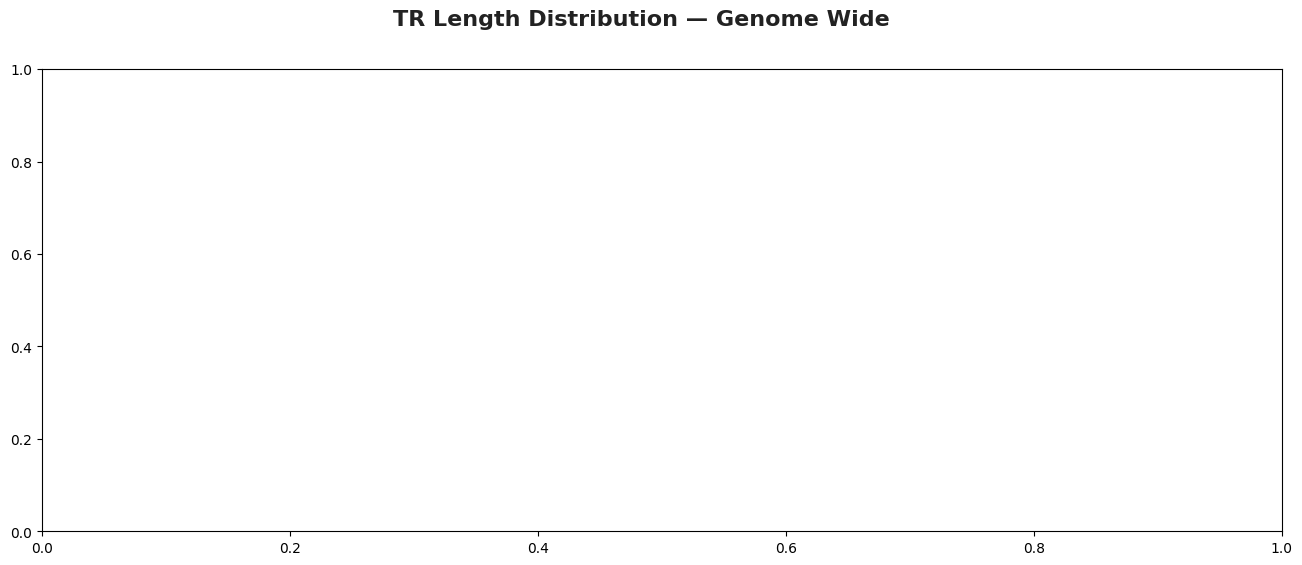

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 – TR Length Distribution (genome-wide)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("TR Length Distribution — Genome Wide",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222")

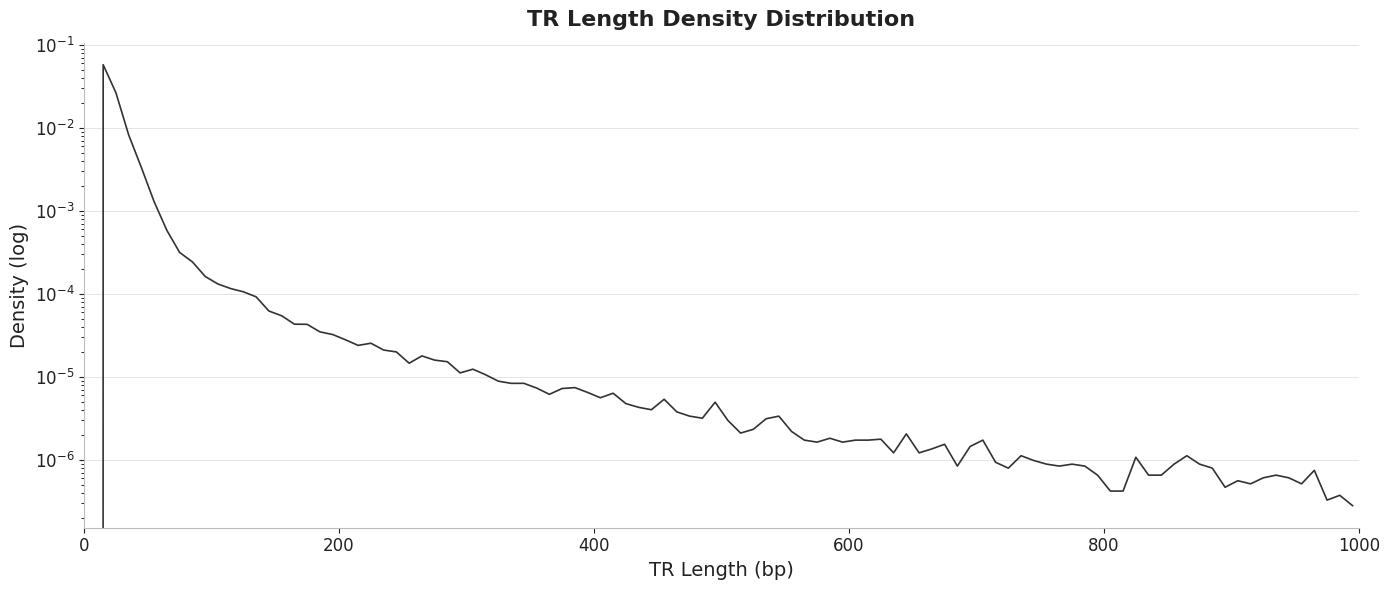

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

data = df_strkit_child["TR_length"].dropna()
data = data[data > 0]

MAX_BP = 1000
BINS   = 100

counts, bin_edges = np.histogram(data[data <= MAX_BP], bins=BINS, range=(0, MAX_BP))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width   = bin_edges[1] - bin_edges[0]
density     = counts / (len(data) * bin_width)

ax.plot(bin_centers, density, color="#333333", linewidth=1.2)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.LogFormatterExponent(base=10))
ax.set_ylabel("Count (log)", fontsize=LABEL_SIZE, color="#222")
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.set_xlim(0, MAX_BP)
ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
ax.set_ylabel("Density (log)",   fontsize=LABEL_SIZE, color="#222")
ax.set_title("TR Length Density Distribution",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_density.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
# ── Plot ──────────────────────────────────────────────────────────

# Left: full range log scale
# ax = axes[0]
# ax.set_facecolor(BG)
# bins_log = np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 80)
# ax.hist(lengths, bins=bins_log, color="#2196f3", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_xscale("log")
# ax.set_title("Full Range (log scale)", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)",  fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",           fontsize=LABEL_SIZE, color="#222")

# Right: zoomed ≤ 200 bp
# ax = axes
# ax.set_facecolor(BG)
# ax.hist(lengths[lengths <= 10000], bins=60, color="#43a047", alpha=0.85,
#         edgecolor="white", linewidth=0.3)
# ax.set_title("Zoomed ≤ 1000 bp", fontsize=TITLE_SIZE - 2, color="#222")
# ax.set_xlabel("TR Length (bp)", fontsize=LABEL_SIZE, color="#222")
# ax.set_ylabel("Count",          fontsize=LABEL_SIZE, color="#222")

# # for ax in axes:
# #     ax.tick_params(colors="#222", labelsize=TICK_SIZE)
# #     ax.spines[["top", "right"]].set_visible(False)
# #     ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
# #     ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7)
# #     ax.set_axisbelow(True)

# plt.tight_layout()
# #plt.savefig("plot_tr_length_distribution.png", dpi=180,
#  #           bbox_inches="tight", facecolor=BG)
# plt.show()

<ipython-input-21-ea725f310d42>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20b", len(chroms))


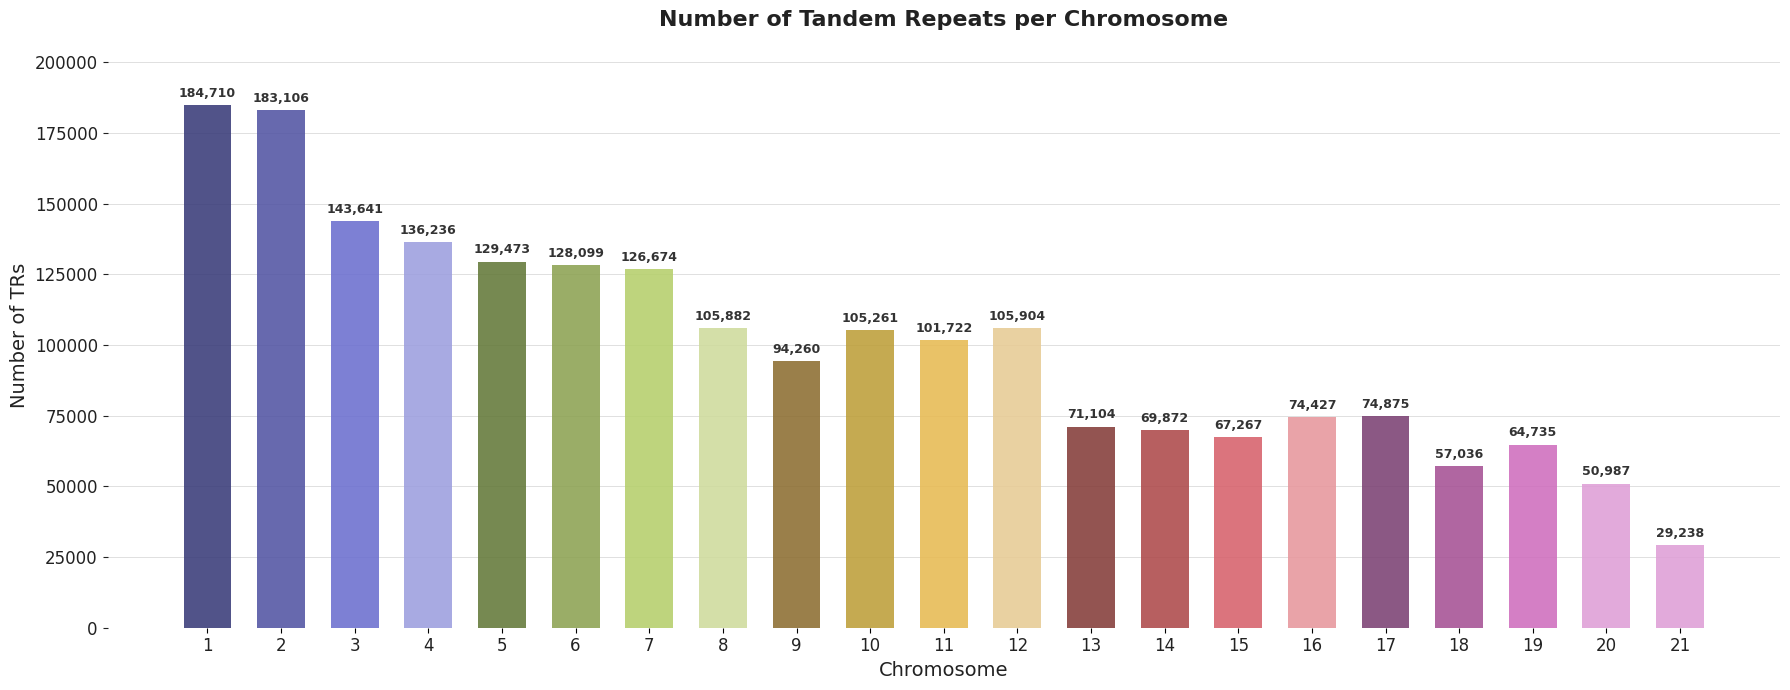

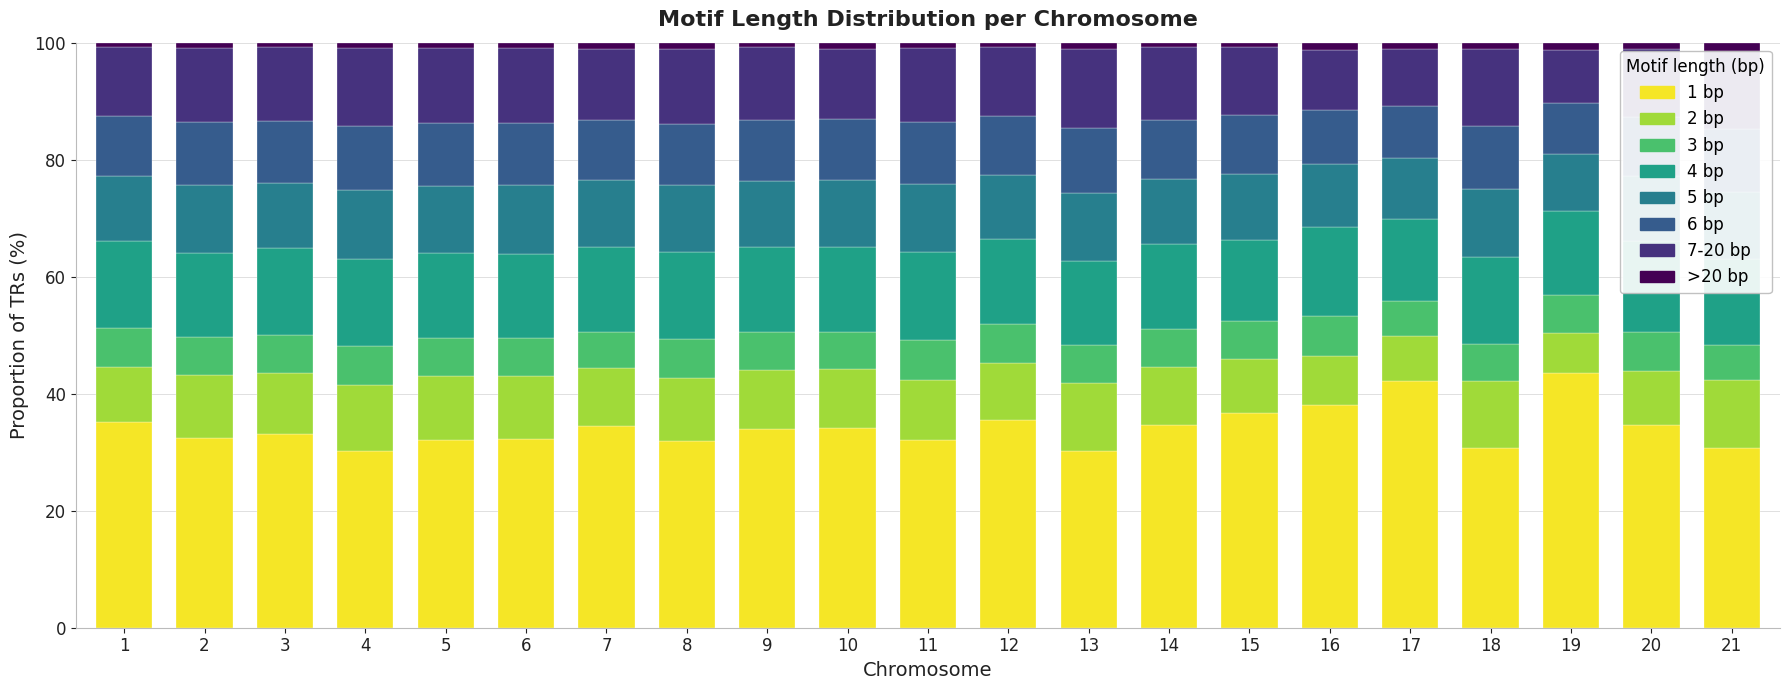

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PLOT 2 – Number of TRs per Chromosome
# ══════════════════════════════════════════════════════════════════
canon_df = df_strkit_child[df_strkit_child["CHROM"].isin(CHR_ORDER)]
counts   = canon_df.groupby("CHROM").size()
chroms   = sort_chroms(counts.index)
counts   = counts.reindex(chroms, fill_value=0)

cmap   = plt.cm.get_cmap("tab20b", len(chroms))
colors = [cmap(i) for i in range(len(chroms))]

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs   = np.arange(len(chroms))
bars = ax.bar(xs, counts.values, width=0.65, color=colors,
              alpha=0.88, linewidth=0, zorder=3)

for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            cnt + counts.max() * 0.01,
            f"{cnt:,}", ha="center", va="bottom",
            fontsize=ANNOT_SIZE, color="#333", fontweight="bold")

ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Number of TRs",  fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",     fontsize=LABEL_SIZE, color="#222")
ax.set_title("Number of Tandem Repeats per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(axis="y", colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_tr_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ══════════════════════════════════════════════════════════════════
# PLOT 3 – Motif Proportion per Chromosome (stacked bar)
# ══════════════════════════════════════════════════════════════════
def classify_motif_size(size):
    if size == 1:    return "1"
    elif size == 2:  return "2"
    elif size == 3:  return "3"
    elif size == 4:  return "4"
    elif size == 5:  return "5"
    elif size == 6:  return "6"
    elif size <= 20: return "7-20"
    else:            return ">20"

CATEGORIES = ["1", "2", "3", "4", "5", "6", "7-20", ">20"]
COLORS = {
    "1":    "#f5e626", "2": "#a0da39", "3":    "#4ac16d",
    "4":    "#1fa187", "5": "#277f8e", "6":    "#365c8d",
    "7-20": "#46327e", ">20":          "#440154",
}

df["MOTIF_CLASS"] = df["MOTIF_SIZE"].apply(classify_motif_size)
plot_df = df[df["CHROM"].isin(CHR_ORDER[:-1])].copy()  # exclude chrM
chroms  = [c for c in CHR_ORDER if c in plot_df["CHROM"].values]

counts_m = (
    plot_df.groupby(["CHROM", "MOTIF_CLASS"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=chroms, columns=CATEGORIES, fill_value=0)
)
proportions = counts_m.div(counts_m.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

xs      = np.arange(len(chroms))
bar_w   = 0.7
bottoms = np.zeros(len(chroms))

for cat in CATEGORIES:
    vals = proportions[cat].values
    ax.bar(xs, vals, width=bar_w, bottom=bottoms,
           color=COLORS[cat], linewidth=0.2, edgecolor="white")
    bottoms += vals

ax.set_xlim(-0.6, len(chroms) - 0.4)
ax.set_ylim(0, 100)
ax.set_xticks(xs)
ax.set_xticklabels([c.replace("chr", "") for c in chroms],
                   fontsize=TICK_SIZE, color="#222")
ax.set_ylabel("Proportion of TRs (%)", fontsize=LABEL_SIZE, color="#222")
ax.set_xlabel("Chromosome",            fontsize=LABEL_SIZE, color="#222")
ax.set_title("Motif Length Distribution per Chromosome",
             fontsize=TITLE_SIZE, fontweight="bold", color="#222", pad=12)
ax.tick_params(colors="#222", labelsize=TICK_SIZE)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(SPINE_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

legend_patches = [mpatches.Patch(color=COLORS[c], label=f"{c} bp")
                  for c in CATEGORIES]
ax.legend(handles=legend_patches, title="Motif length (bp)",
          title_fontsize=TICK_SIZE, fontsize=TICK_SIZE,
          loc="upper right", framealpha=0.9, edgecolor=SPINE_COLOR)

plt.tight_layout()
plt.savefig("plot_motif_proportion_per_chrom.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

No kernel connected

No kernel connected